<a href="https://colab.research.google.com/github/RochaGerd/Chemistry_with_Python/blob/main/Minicurso_VENEBIOTEC_2026_Parte_03_v_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

|    |    |    |
|:----:|:----:|:----:|
|<img src = "https://github.com/RochaGerd/Chemistry_with_Python/blob/main/figures/Imagem_UFPB.gif?raw=true" width = "150"> | <img src = "https://github.com/RochaGerd/Chemistry_with_Python/blob/main/figures/Imagem_DQ_UFPB.png?raw=true" width = "250"> | <img src = "https://github.com/RochaGerd/Chemistry_with_Python/blob/main/figures/LQQC_2024.png?raw=true" width = "300">|

# **[Quimioinformática e Modelagem Molecular — Perspectivas para a Pesquisa em Saúde](https://www.even3.com.br/v-encontro-nacional-de-biotecnologia-da-renorbio-646346/)**

## **Parte 03 de 3 — Química quântica na prática: MOPAC no Colab**

**Prof. Gerd Bruno Rocha** | gbr@academico.ufpb.br

Departamento de Química - UFPB | Laboratório de Química Quântica Computacional (LQQC)

<font color='red'>**Minicurso teórico/prático - V ENEBIOTEC**</font>
Duração total: 3,5 horas | <font color='red'>18-AGO-2026, 14:00 - 17:30</font>

***Versão 4.0 (17-AGO-26)***

---

**Requisitos:** noção inicial de Python e uma conta Google.
**Ambiente:** [Google Colab](https://colab.research.google.com/). Não precisa instalar nada na sua máquina.

---

**Onde me encontrar**

| | |
|---|---|
| Grupo de pesquisa | <https://www.quantum-chem.pro.br/> |
| Repositório do curso | <https://github.com/RochaGerd/Chemistry_with_Python> |
| Lattes | <http://lattes.cnpq.br/9404945858555096> |
| ORCID | 0000-0001-9805-9497 |
| ResearcherID / SCOPUS | G-5115-2010 / 7102518082 |
| Instagram | [@lqqc.ufpb](https://www.instagram.com/lqqcpb/) |
| LinkedIn | <https://www.linkedin.com/in/gerd-bruno-rocha-b32a15351/> |

## **Roteiro do minicurso (outline)**

O minicurso é dividido em três notebooks. Cada um roda de forma independente, e a sequência compõe um percurso: começamos representando moléculas como dados, passamos por como elas se encaixam e se movem, e terminamos observando os elétrons.

| Notebook | Assunto | Ambiente |
|---|---|---|
| Parte 1 | Quimioinformática, CADD e QSAR | CPU |
| Parte 2 | Docking e dinâmica molecular | GPU |
| **Parte 3 (este)** | **Estrutura eletrônica com métodos semiempíricos** | **CPU** |

---

### **Código de cores**

<font color='green'>**Verde**</font>: conteúdo trabalhado com a audiência durante o minicurso. É onde executamos código junto.

<font color='magenta'>**Magenta com "(opcional)"**</font>: material de consulta ou desafios. Não é executado em sala, e fica disponível para exploração posterior.

---
# <font color='green'> **1. Apresentação**

## <font color='green'> **1.1 Objetivos**</font>

1. Aproximar a programação de quem trabalha com química, biologia, farmácia e biotecnologia.
2. Usar modelagem e simulação molecular como ferramenta de aprendizado, não só de pesquisa.
3. Mostrar o que pode ser feito com esses métodos e, principalmente, que resultados podemos produzir.
4. Deixar cada participante com um ambiente que funciona, é gratuito e é reproduzível.

## <font color='green'> **1.2 Público-alvo**</font>

Estudantes de graduação e pós sem experiência prévia com modelagem molecular, com pouca base de Python, e pesquisadores que querem ampliar o repertório computacional em quimioinformática e bioinformática. Se você nunca escreveu uma linha de Python, ainda dá para acompanhar: as células estão prontas, basta executar e ler o que acontece.

## <font color='green'>**1.3 Ementa da Parte 3**</font>

- Fundamentos dos métodos semiempíricos de estrutura eletrônica (aproximação NDDO).
- MOPAC: arquivo de entrada, palavras-chave, arquivos de saída.
- Duas formas de rodar: linha de comando e biblioteca Python (ASE).
- Conversão entre formatos moleculares (SMILES, XYZ, PDB, MOP) com RDKit e Open Babel.
- Propriedades calculadas: calor de formação, orbitais de fronteira, momento de dipolo, cargas.
- Reações isodésmicas como estratégia de cancelamento de erro.
- Cálculo de proteínas com escalonamento linear (MOZYME) e solvatação implícita (COSMO).
- Automação de cálculos em lote com Python e organização de resultados em DataFrame.

## <font color='green'>**1.4 Habilidades e competências**</font>

Ao final desta parte, você deve conseguir:

- Montar do zero um ambiente de química computacional no Colab.
- Escrever um arquivo de entrada do MOPAC e interpretar a saída.
- Converter estruturas entre os formatos usados na área.
- Automatizar dezenas de cálculos sem clicar em nada.
- Julgar quando um resultado semiempírico é confiável e quando ele é só um número.

## <font color='green'> **1.5 Sobre a autoria, as ferramentas e o uso de IA**</font>

> ***Disclaimer***: **muitos dos códigos aqui apresentados foram retirados de portais, repositórios, livros, apostilas e tutoriais e adaptados, em alguns casos, para melhorar a apresentação do minicurso/disciplina. Em alguns casos, foram feitas correções e atualizações nos códigos para melhor funcionamento nos sistemas operacionais atuais, sempre alinhado com o propósito deste minicurso/disciplina. Também, em algumas partes, foram feitas consultas a *chatbots* especializados em produção de códigos (Gemini, Claude e ChatGPT). Nesses casos, foram feitas testagem e correção dos códigos. Ainda se recorreu a *chatbots* para organização de tabelas, equações e formatações de textos em markdown. Tudo foi checado ao final e atestado para manter o rigor científico, acadêmico e didático. Por todo o conteúdo, o autor desse notebook assume total responsabilidade.**

A declaração acompanha as orientações vigentes do CNPq e do MEC sobre transparência no uso de inteligência artificial generativa em atividades de pesquisa e de ensino: a ferramenta é declarada, o uso é descrito, e a responsabilidade pelo conteúdo permanece integralmente humana.

Registram-se também os programas de código aberto sobre os quais este material se apoia: MOPAC, Open Babel, RDKit, ASE, py3Dmol e a biblioteca `rmsd`. Todos estão citados na seção de referências.

## <font color='green'>**1.6 Como navegar neste notebook**</font>

Abra o índice lateral do Colab (ícone de lista com marcadores, na barra da esquerda). Todas as seções estão numeradas e aninhadas, então dá para pular direto para onde você quiser.

Rode as células na ordem, pelo menos na primeira passada. Várias dependem de arquivos gerados pelas anteriores.

Se a sessão do Colab cair (acontece, principalmente se a aba ficar parada), tudo que foi instalado se perde. Nesse caso, volte para a seção 2 e rode de novo.

## <font color='green'>**1.7 Material de apoio**</font>

**Python em Química**

1. *Aprendendo Química com Python*, Rodrigo Queiroz e Gerd Rocha, 2021 - [repositório](https://github.com/pythonchembook) | [compra](https://www.amazon.com/Aprendendo-Qu%C3%ADmica-com-python-Portuguese/dp/B09LGSG6TY)
2. J. Mueller. *Começando a Programar em Python Para Leigos*. Alta Books, 2020.
3. A. Downey. *Pense em Python*. Novatec, 2016 - [versão online](https://penseallen.github.io/PensePython2e/)

**Cursos e notebooks abertos**

- <https://weisscharlesj.github.io/SciCompforChemists/notebooks/introduction/intro.html>
- <https://rwexler.github.io/comp-prob-solv/intro.html>
- <https://tmfilho.github.io/pyestbook/intro.html>
- <https://github.com/gcpeixoto/lecture-ipynb>
- <https://henriqueajnb.github.io/python-para-todos/intro.html>
- <https://github.com/salvianoleao/Introducao-ao-Jupyter>
- <https://python-guide-pt-br.readthedocs.io/pt_BR/latest/>

**Folhas de referência (cheat sheets)**

- <https://github.com/SamBelkacem/AI-ML-cheatsheets>
- <https://www.datacamp.com/cheat-sheet>
- <https://cheatsheets.zip/>
- <https://matplotlib.org/cheatsheets/>
- <https://cheatography.com/>

---
# <font color='green'>**2. Preparando o ambiente**</font>

O Colab entrega uma máquina virtual limpa a cada sessão. A vantagem é o isolamento: nenhuma instalação afeta a máquina do participante. O custo é ter de refazer o procedimento a cada sessão.

A instalação completa leva entre 4 e 7 minutos. Comece por ela agora e deixe rodando enquanto discutimos a teoria da seção 3.

Uma observação sobre a ordem: o MOPAC vem do `conda-forge`, então o Miniconda precisa ser instalado primeiro. Não pule a 2.2.

## <font color='green'> **2.1 Onde estamos rodando**

Antes de instalar qualquer coisa, vale conferir a máquina que o Colab nos deu. Para esta Parte 3 não precisamos de GPU: os cálculos semiempíricos rodam bem em CPU.

In [ ]:
# Diagnóstico rápido da máquina virtual

import sys, platform, subprocess

print("Python  :", sys.version.split()[0])
print("Sistema :", platform.platform())

try:
    import google.colab
    NO_COLAB = True
    print("Ambiente: Google Colab")
except ImportError:
    NO_COLAB = False
    print("Ambiente: local (fora do Colab)")

# Memória disponível
mem = subprocess.run("free -h | awk '/Mem:/ {print $2}'", shell=True,
                     capture_output=True, text=True).stdout.strip()
print("RAM     :", mem or "não identificada")

# GPU: se nvidia-smi responder, existe placa acessível
gpu = subprocess.run("nvidia-smi --query-gpu=name,memory.total --format=csv,noheader",
                     shell=True, capture_output=True, text=True)
if gpu.returncode == 0 and gpu.stdout.strip():
    print("GPU     :", gpu.stdout.strip())
else:
    print("GPU     : nenhuma (para esta Parte 3, sem problema)")

Python  : 3.12.13
Sistema : Linux-6.6.122+-x86_64-with-glibc2.35
Ambiente: Google Colab
RAM     : 12Gi
GPU     : nenhuma (para esta Parte 3, sem problema)


## <font color='green'> **2.2 Instalando o Miniconda**

Leva de 1 a 2 minutos. Comece por aqui.

In [ ]:
#@title <font color="green">**2.2.1 Instalar Miniconda (1-2 min)**</font>
import os
import sys

print("Instalando Miniconda...")
os.system("wget -q https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh")
os.system("bash Miniconda3-latest-Linux-x86_64.sh -b -p /usr/local/miniconda")

# Deixa os binários do conda visíveis para o resto da sessão
os.environ['PATH'] += ":/usr/local/miniconda/bin"

# Aceita os termos dos canais e desliga as perguntas interativas
os.system("conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/main")
os.system("conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/r")
os.system("conda config --set always_yes yes")
os.system("conda update -q conda")

print("\n[Python do Colab]")
!python --version
!which python

print("\n[conda]")
!conda --version
!which conda

Instalando Miniconda...

[Python do Colab]
Python 3.12.13
/usr/local/bin/python

[conda]
conda 26.7.0
/usr/local/miniconda/bin/conda


## <font color='green'> **2.3 Instalando MOPAC e as bibliotecas essenciais**

De 3 a 5 minutos. O MOPAC e o Open Babel vêm do `conda-forge` (precisamos dos executáveis, não só das bindings Python). O resto vem do `pip` e vai para o Python do próprio Colab.

O que cada peça faz:

- **MOPAC** - o motor semiempírico. É ele que resolve as equações.
- **Open Babel** - o tradutor universal entre formatos moleculares.
- **RDKit** - constrói moléculas a partir de SMILES e gera conformações 3D.
- **ASE** - dá uma interface Python para o MOPAC (e para dezenas de outros programas).
- **py3Dmol** - visualização 3D dentro do notebook.
- **rmsd** - compara duas geometrias.

In [ ]:
#@title <font color="green">**2.3.1 Instalar MOPAC, Open Babel e bibliotecas Python (3-5 min)**</font>
import os, sys, warnings

# --- executáveis via conda-forge
print("Instalando MOPAC via conda-forge...")
os.system("conda install -c conda-forge mopac -y")

# A trava rígida de versão do conda briga com o Python do Colab. Removendo, os
# pacotes pip continuam indo para o interpretador certo.
!rm -f /usr/local/conda-meta/pinned

print("Instalando OpenBabel..")
os.system("pip install openbabel-wheel")

# --- bibliotecas Python via pip
print("\nInstalando bibliotecas Python...")
for pacote in ["py3Dmol", "rdkit", "ase", "rmsd"]:
    print(f"  - {pacote}")
    os.system(f"pip install -q {pacote}")

# Caminhos que o kernel do Colab às vezes ignora
for caminho in ["/usr/local/lib/python3.12/site-packages",
                "/usr/local/lib/python3.12/dist-packages",
                "/usr/local/lib/site-packages"]:
    if os.path.exists(caminho) and caminho not in sys.path:
        sys.path.append(caminho)
        print(f"  + caminho mapeado: {caminho}")

warnings.filterwarnings("ignore")

print("\nTestando os imports...")
try:
    import rdkit
    import py3Dmol as p3d
    import ase
    import rmsd
    print("\nOK - tudo carregado.")
except ModuleNotFoundError as e:
    print(f"\nERRO: {e}")
    print("Rode 'print(sys.path)' na próxima célula para investigarmos.")

Instalando MOPAC via conda-forge...
Instalando OpenBabel..

Instalando bibliotecas Python...
  - py3Dmol
  - rdkit
  - ase
  - rmsd

Testando os imports...

OK - tudo carregado.


## <font color='green'>**2.4 Conferindo as versões**</font>

Se alguma linha abaixo não retornar nada, algo falhou na 2.3. Rode de novo antes de seguir.

In [ ]:
import rdkit, ase
import py3Dmol as p3d

print("[MOPAC]")
!which mopac
!mopac --version

print("\n[Open Babel]")
!which obabel
!obabel --version

print("\n[Bibliotecas Python]")
print("RDKit   :", rdkit.__version__)
print("ASE     :", ase.__version__)
print("py3Dmol :", p3d.__version__)

[MOPAC]
/usr/local/miniconda/bin/mopac
MOPAC version 23.2.5

[Open Babel]
/usr/local/bin/obabel
No input file or format spec or possibly a misplaced option.
Most options must come after the input files. (-i -o -O -m can be anywhwere.)

Open Babel 3.1.0 -- Feb 17 2026 -- 06:47:59
Usage:
obabel [-i<input-type>] <infilename> [-o<output-type>] -O<outfilename> [Options]
Try  -H option for more information.

[Bibliotecas Python]
RDKit   : 2026.03.5
ASE     : 3.29.0
py3Dmol : 2.5.5


In [ ]:
## Mais Bibliotecas de Python

import os, sys, glob, gzip, warnings
warnings.filterwarnings("ignore")

# A ordem aqui importa. Ao ser importado, o pacote openbabel define as
# variáveis BABEL_LIBDIR e BABEL_DATADIR, sem as quais os executáveis não
# encontram seus plugins e falham com "Unable to LoadAllPlugins".
import openbabel
BIN_OB = os.path.join(os.path.dirname(openbabel.__file__), "bin")
os.environ["PATH"] = BIN_OB + ":" + os.environ["PATH"]

from openbabel import pybel

print("Open Babel:", pybel.ob.OBReleaseVersion())
print("py3Dmol   :", p3d.__version__)
print("executáveis em:", BIN_OB)

Open Babel: 3.1.0
py3Dmol   : 2.5.5
executáveis em: /usr/local/lib/python3.12/dist-packages/openbabel/bin


In [ ]:
#Testando o Open Babel
# Conferência rápida: os dois comandos que usaremos precisam responder.
!obabel -V
!obrms 2>&1 | head -2

Open Babel 3.1.0 -- Feb 17 2026 -- 06:47:59
obrms: Computes the heavy-atom RMSD of identical compound structures.
Usage: obrms reference_file [test_file]


## <font color='green'> **2.5 Baixando os arquivos do curso**</font>

Os exercícios usam arquivos que estão no repositório público do grupo. Clonamos uma vez só, aqui, e as seções 6 e 7 vão buscar o que precisam.

In [ ]:
%%bash
cd /content
if [ ! -d Chemistry_with_Python ]; then
  git clone --depth 1 https://github.com/RochaGerd/Chemistry_with_Python.git
else
  echo "Repositório já está aqui."
fi
echo "---"
ls Chemistry_with_Python/courses/8th_EQC/

---
8a_EQC_2024_en.pdf
exe_1
exe_2
exe_3
exe_4
exe_5
exe_6
Minicurso_Gerd_Rocha_8a_EQC_2024_exercises.pdf
Minicurso_Gerd_Rocha_8a_EQC_2024.pdf
Readme.md
Resumo_Minicurso_8a_EQC_2024.pdf


Cloning into 'Chemistry_with_Python'...
Updating files: 100% (442/442), done.


## <font color='green'> **2.6 Utilitários do notebook**</font>

Duas funções que vamos usar várias vezes: uma para desenhar diagramas e outra para limpar o diretório de trabalho quando algo der errado.

Os diagramas são escritos em [Mermaid](https://mermaid.js.org/) e renderizados pelo serviço mermaid.ink. Se a imagem não aparecer (serviço fora do ar, rede da instituição bloqueando), copie o código do diagrama e cole em <https://mermaid.live>.

In [ ]:
import base64
from IPython.display import Image, display

def mostrar_mermaid(codigo, largura=900):
    '''Renderiza um diagrama Mermaid usando o serviço público mermaid.ink.

    O código-fonte fica visível na própria célula. Para editar, cole em
    https://mermaid.live
    '''
    grafo = base64.urlsafe_b64encode(codigo.strip().encode("utf8")).decode("ascii")
    display(Image(url=f"https://mermaid.ink/img/{grafo}?type=png&bgColor=FFFFFF",
                  width=largura))

def limpar_diretorio():
    '''Apaga os arquivos gerados pelos cálculos em /content.'''
    import glob, os
    n = 0
    for ext in ("mop", "out", "arc", "aux", "log", "html", "den", "res"):
        for f in glob.glob(f"/content/*.{ext}"):
            os.remove(f)
            n += 1
    print(f"{n} arquivo(s) removido(s) de /content")

print("Funções disponíveis: mostrar_mermaid(codigo) e limpar_diretorio()")

Funções disponíveis: mostrar_mermaid(codigo) e limpar_diretorio()


## <font color='magenta'>**2.7 Bibliotecas extras (opcional)**</font>

Estas bibliotecas não são usadas na Parte 3. Elas aparecem nas Partes 1 e 2 e ficam aqui para quem quiser rodar tudo em um ambiente único. Instalação demorada, então pule se estiver acompanhando ao vivo.

In [ ]:
#@title <font color="magenta">**2.7.1 Extras: pdbfixer, biopython, ProLIF, PySCF (opcional, 3-5 min)**</font>
import os

print("pdbfixer (conda-forge)...")
os.system("conda install -c conda-forge pdbfixer -y")

for pacote in ["biopython", "prolif", "pyscf"]:
    print(f"{pacote}...")
    os.system(f"pip install -q {pacote}")

print("\nConferindo:")
for nome, modulo in [("biopython", "Bio"), ("ProLIF", "prolif"), ("PySCF", "pyscf")]:
    try:
        __import__(modulo)
        print(f"  OK   - {nome}")
    except ImportError:
        print(f"  falhou - {nome}")

---
# <font color='magenta'>**3. Fundamentos de estrutura eletrônica**</font>

Antes de discutir o que os métodos semiempíricos aproximam, convém estabelecer o que eles aproximam **em relação a quê**. Este módulo percorre o caminho que vai da equação de Schrödinger eletrônica até o ponto em que o custo se torna proibitivo.

O tratamento é simplificado e prioriza as equações que voltam a aparecer adiante.

## <font color='magenta'>**3.1 O problema eletrônico**</font>

A aproximação de Born-Oppenheimer (1927), discutida na seção 4.6 da Parte 01 a propósito da superfície de energia potencial, separa o movimento nuclear do eletrônico. Fica do outro lado dessa separação o **problema eletrônico**, que é o que a química quântica de fato resolve.

Em unidades atômicas, com os núcleos fixos numa dada geometria, o Hamiltoniano eletrônico é

$$\hat{H}_{\text{el}} = -\frac{1}{2}\sum_{i}^{N}\nabla_i^2 \;-\; \sum_{i}^{N}\sum_{A}^{M}\frac{Z_A}{r_{iA}} \;+\; \sum_{i<j}^{N}\frac{1}{r_{ij}}$$

Os dois primeiros termos são **monoeletrônicos**: energia cinética dos elétrons e atração núcleo-elétron. Cada um pode ser resolvido separadamente para cada elétron. O terceiro termo, a repulsão elétron-elétron, é o que impede a separação de variáveis e torna o problema insolúvel analiticamente para $N>1$.

Toda a química quântica computacional consiste, no fundo, em maneiras diferentes de lidar com esse único termo $1/r_{ij}$. Vale aqui uma observação a mais sobre essa parcela, porque ela organiza a hierarquia inteira de métodos: quanto mais fielmente um método trata a correlação entre os movimentos eletrônicos, mais caro computacionalmente ele é.

## <font color='magenta'>**3.2 Antissimetria e o determinante de Slater**</font>

Elétrons são férmions, e a função de onda precisa ser antissimétrica frente à troca de duas partículas:

$$\Psi(\ldots,\mathbf{x}_i,\ldots,\mathbf{x}_j,\ldots) = -\Psi(\ldots,\mathbf{x}_j,\ldots,\mathbf{x}_i,\ldots)$$

Essa exigência é a forma rigorosa do princípio de exclusão de Pauli. A construção mais simples que a satisfaz é o **determinante de Slater** (1929), montado a partir de $N$ spin-orbitais ortonormais $\chi_i$:

$$\Psi_{\text{SD}} = \frac{1}{\sqrt{N!}}
\begin{vmatrix}
\chi_1(\mathbf{x}_1) & \chi_2(\mathbf{x}_1) & \cdots & \chi_N(\mathbf{x}_1)\\
\chi_1(\mathbf{x}_2) & \chi_2(\mathbf{x}_2) & \cdots & \chi_N(\mathbf{x}_2)\\
\vdots & \vdots & \ddots & \vdots\\
\chi_1(\mathbf{x}_N) & \chi_2(\mathbf{x}_N) & \cdots & \chi_N(\mathbf{x}_N)
\end{vmatrix}$$

A troca de dois elétrons corresponde a trocar duas linhas do determinante, o que inverte o sinal: a antissimetria decorre da estrutura algébrica. E se dois spin-orbitais forem iguais, duas colunas coincidem e o determinante se anula, que é precisamente o enunciado de Pauli.

Um único determinante descreve elétrons que se movem no **campo médio** uns dos outros. Ele captura a correlação entre elétrons de mesmo spin, chamada correlação de troca ou de Fermi, e ignora a correlação instantânea entre elétrons de spins opostos. Essa lacuna é o objeto de todos os métodos pós-Hartree-Fock.

## <font color='magenta'>**3.3 Hartree-Fock, LCAO e onde está o custo**</font>

Aplicando o princípio variacional ao determinante de Slater, com a restrição de ortonormalidade dos orbitais, chega-se às equações de Hartree (1928) e Fock (1930):

$$\hat{f}(1)\,\chi_i(1) = \varepsilon_i\,\chi_i(1), \qquad
\hat{f}(1) = \hat{h}(1) + \sum_{j}^{N}\left[\hat{J}_j(1) - \hat{K}_j(1)\right]$$

O termo $\hat{h}$ reúne as contribuições monoeletrônicas. O **operador de Coulomb** $\hat{J}_j$ descreve a repulsão eletrostática clássica contra a densidade média do orbital $j$. O **operador de troca** $\hat{K}_j$ não tem análogo clássico: é consequência direta da antissimetria e mantém afastados os elétrons de mesmo spin.

Repare na estrutura dessas equações: o operador de Fock depende dos orbitais que são sua própria solução. É um problema de autoconsistência, resolvido iterativamente pelo procedimento **SCF** (*self-consistent field*). Parte-se de orbitais tentativa, constrói-se $\hat{f}$, resolve-se, e repete-se até que a densidade eletrônica pare de mudar dentro de uma tolerância. Quando o MOPAC imprime o número de ciclos SCF, é desse laço que se trata.

**LCAO e Roothaan-Hall.** Para moléculas, os orbitais moleculares são expandidos como combinação linear de funções de base centradas nos átomos, $\psi_i = \sum_{\mu}^{K} C_{\mu i}\,\phi_\mu$. Substituindo na equação de Fock, Roothaan e Hall (1951) transformaram o problema diferencial num problema matricial de autovalores generalizado:

$$\mathbf{F}\mathbf{C} = \mathbf{S}\mathbf{C}\boldsymbol{\varepsilon}$$

onde $\mathbf{S}$ é a matriz de recobrimento, $S_{\mu\nu}=\langle\phi_\mu|\phi_\nu\rangle$. Essa reformulação é o que tornou a química quântica computacional possível: passou-se de resolver equações integro-diferenciais para diagonalizar matrizes.

**O gargalo.** Está nas integrais de repulsão eletrônica de dois elétrons e quatro índices,

$$(\mu\nu|\lambda\sigma) = \iint \phi_\mu(1)\phi_\nu(1)\,\frac{1}{r_{12}}\,\phi_\lambda(2)\phi_\sigma(2)\;\mathrm{d}\tau_1\mathrm{d}\tau_2$$

cujo número cresce formalmente com $K^4$. Uma base de 500 funções gera cerca de $6\times10^{9}$ integrais únicas. Técnicas de simetria reduzem isso na prática um pouco, mas usando esse algoritmo convencional, o escalonamento formal $\mathcal{O}(K^4)$ permanece e é essa a razão de nem mesmo o Hartree-Fock não ser aplicável a uma proteína.

Convém classificar essas integrais pelo número de **centros atômicos** envolvidos. Se $\phi_\mu$ está no átomo $A$, $\phi_\nu$ em $B$, $\phi_\lambda$ em $C$ e $\phi_\sigma$ em $D$, a integral pode envolver de um a quatro centros distintos. As de três e quatro centros são a esmagadora maioria e as mais caras. É sobre elas que a estratégia semiempírica atua, como veremos na seção 4.2.

## <font color='magenta'>**3.4 Correlação eletrônica e o teorema de Koopmans**</font>

**O que falta no Hartree-Fock.** A energia de correlação é definida como o que sobra:

$$E_{\text{corr}} = E_{\text{exata}}^{\text{não relativística}} - E_{\text{HF}}$$

Em termos absolutos ela é pequena, tipicamente menos de 1% da energia eletrônica total. Em termos químicos é decisiva: a **dispersão de London é puramente um efeito de correlação**, e o Hartree-Fock, por construção, não descreve nenhuma atração dispersiva. Dois anéis aromáticos empilhados, interação onipresente em complexos proteína-ligante, aparecem como puramente repulsivos num cálculo HF.

Esse ponto reaparece na seção 4.4, quando discutirmos por que as correções de dispersão se tornaram parte integrante dos métodos semiempíricos modernos.

**O teorema de Koopmans.** Koopmans (1934) mostrou que, dentro da aproximação de orbitais congelados, as energias orbitais têm significado físico direto:

$$\text{PI} \approx -\varepsilon_{\text{HOMO}}, \qquad \text{AE} \approx -\varepsilon_{\text{LUMO}}$$

O resultado é aproximado, porque despreza a relaxação orbital do íon e o erro de correlação, e os dois erros se cancelam parcialmente no caso do potencial de ionização. Ainda assim, é a base conceitual de uma família de descritores usados em QS(P)AR. As energias orbitais que o MOPAC imprime, e que leremos na seção 5.5, são exatamente essas.

## <font color='magenta'>**3.5 Além do Hartree-Fock: MP2, coupled cluster e DFT (opcional)**</font>

**Teoria de perturbação de Møller-Plesset.** Møller e Plesset (1934) tomaram o operador de Fock como Hamiltoniano de ordem zero e trataram a diferença como perturbação. A correção de segunda ordem, MP2, é uma soma sobre excitações duplas de orbitais ocupados $i,j$ para virtuais $a,b$:

$$E^{(2)} = \sum_{i<j}^{\text{ocup}}\sum_{a<b}^{\text{virt}} \frac{\left|\langle ij\|ab\rangle\right|^2}{\varepsilon_i+\varepsilon_j-\varepsilon_a-\varepsilon_b}$$

O denominador é sempre negativo, portanto $E^{(2)}<0$: a correlação sempre estabiliza. O MP2 recupera tipicamente de 80 a 90% da energia de correlação e é o método correlacionado mais barato, com escalonamento $\mathcal{O}(N^5)$.

**Coupled cluster.** O ansatz exponencial $\Psi_{\text{CC}} = e^{\hat{T}}\,\Psi_{\text{HF}}$ garante consistência com o tamanho do sistema, propriedade que o CI truncado não tem. Truncando em duplas e tratando as triplas de forma perturbativa, obtém-se o **CCSD(T)** (Raghavachari e colaboradores, 1989), tomado como referência do campo: numa base suficientemente grande, reproduz energias de interação não covalentes com erro abaixo de 0,2 kcal/mol. O preço é o escalonamento $\mathcal{O}(N^7)$, de modo que dobrar o tamanho do sistema multiplica o custo por 128.

**Teoria do funcional da densidade.** Hohenberg e Kohn (1964) provaram que a densidade eletrônica do estado fundamental determina univocamente o potencial externo e, portanto, tudo sobre o sistema, e que existe um funcional $E[\rho]$ cujo mínimo é a energia do estado fundamental. Kohn e Sham (1965) contornaram o desconhecimento da energia cinética como funcional da densidade introduzindo um sistema fictício de elétrons não interagentes que reproduz a densidade exata:

$$E[\rho] = T_s[\rho] + \int v_{\text{ext}}(\mathbf{r})\rho(\mathbf{r})\,\mathrm{d}\mathbf{r} + J[\rho] + E_{\text{xc}}[\rho]$$

onde $E_{\text{xc}}$, o funcional de troca e correlação, absorve tudo o que é desconhecido. A DFT de Kohn-Sham seria exata se $E_{\text{xc}}$ fosse conhecido. Como não é, aproxima-se, e aí a DFT se separa dos métodos de função de onda: nestes existe um caminho sistemático de melhoria em direção ao resultado exato; em DFT não existe.

Perdew organizou os funcionais em degraus de sofisticação crescente:

| Degrau | Ingredientes | Exemplos |
|---|---|---|
| LDA | densidade local | SVWN |
| GGA | densidade e seu gradiente | PBE, BLYP |
| meta-GGA | acrescenta a densidade de energia cinética | TPSS, SCAN, M06-L |
| híbrido | acrescenta troca exata de Hartree-Fock | B3LYP, PBE0, M06-2X |
| duplo-híbrido | acrescenta correlação de perturbação | B2PLYP, DSD-BLYP |

**Dispersão em DFT.** Funcionais locais e semilocais não descrevem dispersão de London, porque ela é efeito de correlação de longo alcance e não local. A solução usual soma uma correção empírica aos pares atômicos, na formulação D3 de Grimme e colaboradores (2010), depois estendida para D4. Para qualquer sistema de interesse biológico, cálculo DFT sem correção de dispersão é cálculo incompleto. Para orientação prática sobre escolha de funcional e base, a revisão de Bursch, Mewes, Hansen e Grimme (2022) é a referência atual mais útil.

## <font color='magenta'>**3.6 Funções de base e erro de superposição (opcional)**</font>

**Do orbital de Slater ao gaussiano.** Orbitais do tipo Slater, $e^{-\zeta r}$, têm a forma fisicamente correta: cúspide no núcleo e decaimento exponencial. As integrais de dois elétrons entre funções centradas em quatro átomos diferentes, porém, não têm solução analítica.

Boys (1950) propôs usar gaussianas, $e^{-\alpha r^2}$, porque o produto de duas gaussianas centradas em pontos distintos é outra gaussiana centrada num ponto intermediário. Isso reduz integrais de quatro centros a integrais de dois centros, com fórmula fechada. A forma é pior, sem cúspide e com decaimento rápido demais, e a solução prática é **contrair** várias gaussianas primitivas para imitar um orbital de Slater.

**Notação.** Na nomenclatura de Pople, `6-31G(d,p)` significa: seis primitivas contraídas para os orbitais internos; a valência dividida em duas funções, uma com três primitivas e outra com uma; e funções de polarização do tipo $d$ nos átomos pesados e $p$ nos hidrogênios. As funções de polarização permitem que a densidade se deforme na formação de ligações. Funções **difusas**, marcadas com `+`, estendem a densidade para longe do núcleo e são indispensáveis para ânions, pares isolados e complexos ligados por ligação de hidrogênio.

Cabe registrar o contraste com o que veremos adiante: nos métodos semiempíricos a base é **mínima e fixa**, restrita à valência. Não há escolha de base a fazer, e tampouco há caminho de melhoria por esse lado.

**Erro de superposição de base.** Ao calcular a energia de interação de um dímero como $\Delta E = E_{AB} - E_A - E_B$, o complexo dispõe das funções de base dos dois monômeros, enquanto cada monômero isolado dispõe apenas das suas. O complexo é artificialmente estabilizado. Esse erro pode chegar a vários kcal/mol em bases pequenas, e sempre no sentido de exagerar a interação. A correção de *counterpoise*, de Boys e Bernardi (1970), recalcula os monômeros na base completa do dímero:

$$\Delta E^{\text{CP}} = E_{AB}^{AB} - E_A^{AB} - E_B^{AB}$$

Energia de interação reportada sem informação sobre contrapeso omite dado necessário ao julgamento do resultado.

## <font color='magenta'>**3.7 Custo computacional: a hierarquia de métodos**</font>

A seleção de um método em química computacional exige um balanço contínuo entre **exatidão química** (representação explícita da estrutura eletrônica) e **viabilidade computacional** (tamanho do sistema e tempo de amostragem).

| Método | Escalonamento Formal | Tamanho Típico Viável | Aplicação Característica |
| --- | --- | --- | --- |
| **CCSD(T)** | $\mathcal{O}(N^7)$ | 10 a 30 átomos | Padrão-ouro (*gold standard*) para calibração e referência de alta exatidão. |
| **MP2** | $\mathcal{O}(N^5)$ | 50 a 100 átomos | Energias de interação intermolecular e sistemas diméricos. |
| **DFT Híbrida** | $\mathcal{O}(N^4)$ a $\mathcal{O}(N^3)$* | 100 a 1000 átomos | Otimização de geometria, mecanismos reacionais e espectroscopia. |
| **Hartree-Fock (HF)** | $\mathcal{O}(N^4)$ | 100 a 500 átomos | Ponto de partida para métodos correlacionados; raramente usado isoladamente. |
| **Semiempírico (NDDO)** | $\mathcal{O}(N^2)$ a $\mathcal{O}(N^3)$ | $10^3$ a $10^4$ átomos | Sítios ativos proteicos, *re-ranking* de *poses* e triagem virtual. |
| **Semiempírico (MOZYME)** | $\mathcal{O}(N^{1.5})$ (quase-linear) | $\ge 10^4$ átomos | Macromoléculas e proteínas inteiras via orbitais localizados. |
| **Mecânica Molecular (MM)** | $\mathcal{O}(N)$ a $\mathcal{O}(N \log N)$ | $10^5$ a $10^6$ átomos | Dinâmica molecular, *docking* e simulações com solvente explícito. |

**Reduzido em implementações modernas com aproximações de ajustamento de densidade (Density Fitting / RI).*

---

### A Lógica da Hierarquia: Filtragem em Cascata

A aplicação prática dessa matriz fundamenta-se na **filtragem em cascata** (discutida na Seção 7.7 da Parte 02): emprega-se a ferramenta computacional mais rápida que retenha a química necessária para responder à pergunta biológica, reservando os métodos quânticos de alto custo exclusivamente para o subconjunto refinado que sobreviveu aos filtros anteriores.

### A Lacuna Dimensional dos Métodos Semiempíricos

O sítio de ligação de um complexo proteína-ligante compreende tipicamente entre 500 e 2000 átomos, enquanto uma proteína de pequeno porte possui alguns milhares de átomos. Esta dimensão evidencia uma lacuna metodológica clássica:

* **Mecânica Molecular (MM):** Suporta a escala do sistema com facilidade, mas **faltam os elétrons**, sendo incapaz de descrever efeitos de polarização, transferência de carga, excitações eletrônicas ou reatividade química.
* **Teoria do Funcional da Densidade (DFT):** Trata a estrutura eletrônica com rigor, contudo apresenta **custo computacional proibitivo** para triagens de rotina em sistemas desse porte.

Os métodos semiempíricos preenchem exatamente esse nicho intermediário: ao negligenciar integrais de dois elétrons de menor magnitude e parametrizar termos com dados experimentais e quânticos de referência, viabilizam o tratamento quântico do sítio ativo a um custo computacional viável.

A célula a seguir traduz visualmente esse compromisso entre tamanho do sistema e tempo de cálculo.

---

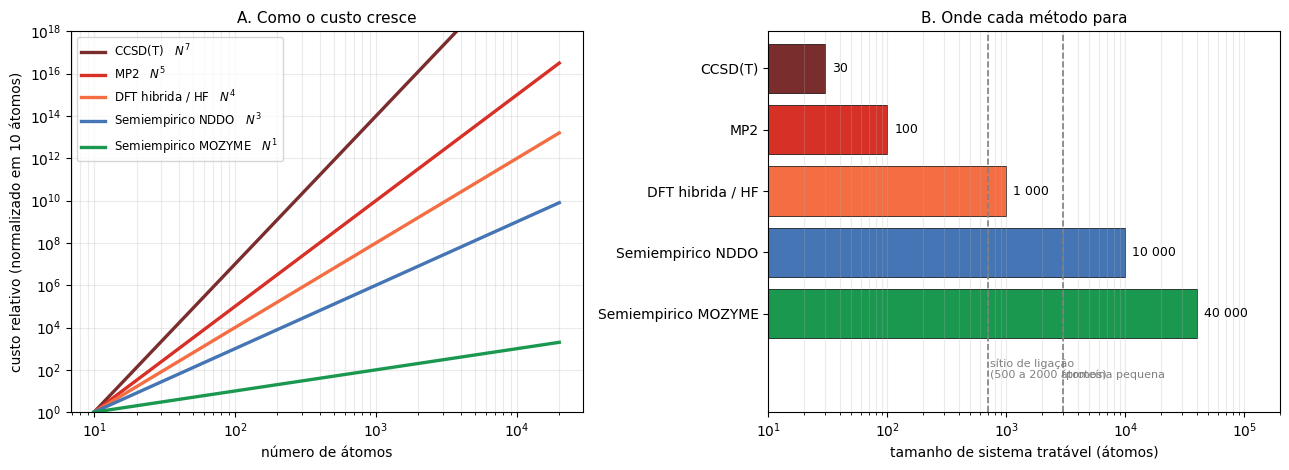

A lacuna que os métodos semiempíricos ocupam:

  mecânica molecular   -> 10^5 átomos, sem elétrons
  DFT híbrida          -> 10^2 átomos, com elétrons
  semiempírico         -> 10^3 a 10^4 átomos, com elétrons

Custo relativo para dobrar o sistema, de 1000 para 2000 átomos:
  CCSD(T)                x     128
  MP2                    x      32
  DFT hibrida / HF       x      16
  Semiempirico NDDO      x       8
  Semiempirico MOZYME    x       2


In [ ]:
#@title <font color='magenta'> 3.7 — O custo de cada método, em escala
# Duas leituras do mesmo argumento: como o custo cresce com o tamanho
# do sistema, e onde cada método deixa de ser praticável.

import numpy as np
import matplotlib.pyplot as plt

N = np.logspace(1, 4.3, 400)          # numero de atomos

METODOS = [
    ("CCSD(T)",              7, "#7a2d2d", 30),
    ("MP2",                  5, "#d73027", 100),
    ("DFT hibrida / HF",     4, "#f46d43", 1000),
    ("Semiempirico NDDO",    3, "#4575b4", 10000),
    ("Semiempirico MOZYME",  1, "#1a9850", 40000),
]

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))

# ---- A: escalonamento formal, normalizado em N = 10 --------------------
for nome, p, cor, _ in METODOS:
    custo = (N / 10.0) ** p
    ax[0].plot(N, custo, lw=2.4, color=cor, label=f"{nome}   $N^{{{p}}}$")

ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].set_xlabel("número de átomos")
ax[0].set_ylabel("custo relativo (normalizado em 10 átomos)")
ax[0].set_title("A. Como o custo cresce", fontsize=11)
ax[0].legend(fontsize=8.5, loc="upper left")
ax[0].grid(alpha=0.25, which="both")
ax[0].set_ylim(1, 1e18)

# ---- B: faixa praticavel de cada metodo --------------------------------
rotulos = [m[0] for m in METODOS][::-1]
limites = [m[3] for m in METODOS][::-1]
cores = [m[2] for m in METODOS][::-1]

barras = ax[1].barh(rotulos, limites, color=cores, edgecolor="k", linewidth=0.5)
for b, v in zip(barras, limites):
    ax[1].text(v * 1.15, b.get_y() + b.get_height() / 2, f"{v:,}".replace(",", " "),
               va="center", fontsize=9)

for x, rot in [(700, "sítio de ligação\n(500 a 2000 átomos)"),
               (3000, "proteína pequena")]:
    ax[1].axvline(x, ls="--", lw=1.2, color="gray")
    ax[1].text(x * 1.05, -1.05, rot, fontsize=8, color="gray")

ax[1].set_ylim(-1.6, 4.6)
ax[1].set_xscale("log")
ax[1].set_xlabel("tamanho de sistema tratável (átomos)")
ax[1].set_title("B. Onde cada método para", fontsize=11)
ax[1].grid(axis="x", alpha=0.25, which="both")
ax[1].set_xlim(10, 2e5)

plt.tight_layout()
plt.show()

print("A lacuna que os métodos semiempíricos ocupam:\n")
print("  mecânica molecular   -> 10^5 átomos, sem elétrons")
print("  DFT híbrida          -> 10^2 átomos, com elétrons")
print("  semiempírico         -> 10^3 a 10^4 átomos, com elétrons\n")
print("Custo relativo para dobrar o sistema, de 1000 para 2000 átomos:")
for nome, p, _, _ in METODOS:
    print(f"  {nome:22s} x {2**p:>7.0f}")

### <font color='magenta'> **3.7.1 Diagrama: o mapa dos métodos**</font>

O código Mermaid está na célula abaixo. Para editar, copie e cole em <https://mermaid.live>.

In [ ]:
diagrama_mapa = """
flowchart TD
    SCH["Equação de Schrödinger eletrônica<br/>o termo 1/r_ij impede a solução analítica"]
    SCH --> SD["Determinante de Slater<br/>antissimetria, campo médio"]
    SD --> HF["Hartree-Fock<br/>SCF + Roothaan-Hall<br/>custo O(K^4) nas integrais"]

    HF --> POS["Pos-Hartree-Fock<br/>MP2 O(N^5)<br/>CCSD(T) O(N^7)"]
    HF --> DFT["DFT de Kohn-Sham<br/>funcional Exc aproximado<br/>+ correção de dispersão"]
    HF --> SEMI["Semiempíricos<br/>elimina integrais<br/>e parametriza o resto"]

    POS --> REF["Referência<br/>10 a 150 atomos"]
    DFT --> MED["Geometria e mecanismo<br/>100 a 1000 atomos"]
    SEMI --> GRA["Sitio ativo e proteína<br/>10^3 a 10^4 atomos"]

    style SEMI fill:#d6f5d6,stroke:#2d7a2d
    style GRA fill:#d6f5d6,stroke:#2d7a2d
    style HF fill:#d6e4f5,stroke:#2d5a7a
"""

mostrar_mermaid(diagrama_mapa, largura=760)

---
# <font color='magenta'>**4. Métodos semiempíricos**</font>

## <font color='magenta'> **4.1 A lacuna que estes métodos ocupam**</font>

Existe uma lacuna entre os dois extremos da modelagem molecular. De um lado, a mecânica molecular trata centenas de milhares de átomos e não tem elétrons: não descreve polarização, transferência de carga, quebra de ligação nem coordenação a metal. De outro, a DFT descreve tudo isso muito bem, e não passa de algumas centenas de átomos.

Um sítio de ligação proteína-ligante tem tipicamente entre 500 e 2000 átomos. Uma proteína pequena tem alguns milhares. É exatamente essa a faixa em que os métodos semiempíricos operam, e não por acaso é também a faixa que interessa à química medicinal estrutural.

A proposta é radical em sua economia: manter a estrutura formal do método de Hartree-Fock, com determinante de Slater, campo autoconsistente e matriz de Fock, e **eliminar a maior parte das integrais, substituindo as algumas que são mantidas por parâmetros ajustados a dados experimentais**. O resultado deixa de ser uma aproximação ao Hartree-Fock e passa a ser um modelo próprio, calibrado para reproduzir observáveis químicos importantes, tais como: momento de dipolo, calor de formação, potencial de ionização e geometria molecular, todas a 25 $^\circ\text{C}$.

Essa distinção conceitual, que remonta a Michael Dewar, precisa ficar clara desde já. Um método semiempírico bem parametrizado pode ser **mais acurado que o Hartree-Fock na química em que foi construído**, porque os parâmetros absorvem, de forma implícita, parte da correlação eletrônica que o Hartree-Fock não possui. Em contrapartida, ele não converge para lugar nenhum quando se aumenta a base: vale onde foi parametrizado.

## <font color='magenta'>**4.2 Calor de formação em vez de energia total**</font>

Uma escolha metodológica distingue este método dos demais: a grandeza reportada não é a energia eletrônica total, e sim o **calor de formação**. A conversão é

$$\Delta H_f^{\text{mol}} = E_{\text{elet}}^{\text{mol}} + E_{\text{caroço}}^{\text{mol}} - \sum_A E_{\text{elet}}^{A} + \sum_A \Delta H_f^{A}$$

em que se subtrai a energia eletrônica dos átomos isolados calculada no mesmo modelo e se somam os calores de formação atômicos experimentais.

A lógica é direta. Como os parâmetros foram ajustados contra calores de formação experimentais, é nessa grandeza que o método tem significado. Há ainda um benefício prático: as contribuições térmicas e de energia de ponto zero ficam implicitamente absorvidas nos parâmetros, de modo que o número sai já comparável a dados a 298 K, sem cálculo de frequências.

O revés é que isso mistura energia eletrônica com entalpia. Ao calcular uma diferença de energia entre duas geometrias de um mesmo sistema, o efeito se cancela e não há problema — é o que faremos na Atividade 01-QM do módulo 8. Ao interpretar um $\Delta H$ de ligação, porém, convém lembrar que se trata de uma entalpia efetiva e parametrizada, e não de uma energia livre.

É por essa razão que o MOPAC imprime `FINAL HEAT OF FORMATION` em kcal/mol, e não uma energia eletrônica total em hartrees, como faria um programa *ab initio*.

## <font color='magenta'> **4.3 O que é parametrizado, e contra o quê**</font>

Os parâmetros de cada elemento se distribuem em algumas categorias:

| Categoria | Papel no modelo |
|---|---|
| Energias monoeletrônicas dos orbitais | posiciona os níveis de valência do átomo |
| Expoentes das funções de Slater | define a extensão espacial dos orbitais de valência |
| Parâmetros de ressonância | governa a força das ligações entre átomos |
| Integrais monocêntricas de dois elétrons | repulsão e troca dentro do átomo |
| Parâmetros da repulsão caroço-caroço | ajusta o balanço a distâncias curtas e intermediárias |
| Gaussianas esféricas, nos modelos do tipo AM1 | corrige localmente a curva de repulsão |

O conjunto de treino tradicional reúne **calores de formação, momentos de dipolo, potenciais de ionização e variáveis geométricas**, isto é, comprimentos e ângulos de ligação. O procedimento minimiza uma função de erro ponderada sobre centenas ou milhares de moléculas de referência.

Aqui está a fragilidade estrutural da abordagem, e convém enunciá-la sem rodeios: **um método semiempírico só é confiável para química parecida com a do seu conjunto de treino**. Se ele foi ajustado sobre moléculas orgânicas em equilíbrio, não há garantia alguma sobre estados de transição, espécies exóticas ou geometrias muito distorcidas. Aumentar a base não ajuda, porque a base é fixa. Refinar a integração não ajuda, porque não há integração a refinar.

A pergunta a fazer antes de aceitar qualquer número produzido nas seções seguintes é, portanto, uma só: **este sistema se parece com aquilo contra o que o método foi parametrizado?**

## <font color='magenta'>**4.4 Correções para interações não covalentes**</font>

Paralelamente à evolução dos Hamiltonianos, desenvolveu-se uma estratégia de **correção aditiva pós-SCF** que se mostrou eficaz:

$$E_{\text{total}} = E_{\text{SQM}} + E_{\text{disp}} + E_{\text{H-bond}} + E_{\text{X-bond}}$$

O termo de **dispersão** usa a formulação D3 de Grimme com parâmetros específicos do método semiempírico, e responde diretamente à lacuna identificada na seção 3.4: sem correlação, não há dispersão. O termo de **ligação de hidrogênio**, a função H4 de Řezáč e Hobza (2012), foi redesenhada em relação às versões anteriores para ter superfície de energia potencial suave, o que permitiu seu uso em otimização de geometria e em dinâmica molecular. Há ainda uma correção dedicada à **ligação de halogênio** (Řezáč e Hobza, 2011), que descreve o σ-hole sem recorrer a sítios virtuais.

O resultado merece ser dito com números. Métodos corrigidos como PM6-D3H4 alcançam, para energias de interação não covalentes, acurácia comparável à de DFT com correção de dispersão, em sistemas de até milhares de átomos e com custo ordens de grandeza menor. O desenvolvimento mais recente dessa linha é a função de pontuação **SQM2.20** (Pecina, Fanfrlík, Lepšík e Řezáč, 2024), que alcança correlação média $R^2 = 0{,}69$ com afinidades experimentais no conjunto de referência PL-REX, em nível de acurácia comparável ao de cálculos DFT muito mais caros.

Uma família paralela e igualmente relevante é a dos métodos de **ligação forte** derivados da DFT, GFN1-xTB e GFN2-xTB (Grimme e colaboradores, 2017; Bannwarth e colaboradores, 2019), parametrizados de forma ampla para geometrias, frequências e energias não covalentes, e hoje muito usados para triagem conformacional rápida.

## <font color='magenta'>**4.5 A família de métodos**</font>

Cada método da linhagem NDDO difere pelo conjunto de parâmetros e pela forma funcional dos termos de correção *core-core*.

| Método | Ano | Comentário |
|---|---|---|
| MNDO | 1977 | Primeiro da linhagem NDDO de Dewar. Falha em ligações de hidrogênio. |
| AM1 | 1985 | Dewar e colaboradores. Adiciona gaussianas esféricas ao termo *core-core*, o que resgata a descrição de ligações de hidrogênio. |
| PM3 | 1989 | Stewart. Mesma forma funcional do AM1, mas com parametrização automática e conjunto de dados muito maior. |
| RM1 | 2006 | Reparametrização do AM1 para H, C, N, O, P, S, F, Cl, Br e I, feita por Rocha, Freire, Simas e Stewart. Melhora calores de formação, geometrias e momentos de dipolo mantendo a forma funcional do AM1. |
| PM6 / PM7 | 2007 / 2013 | Stewart. Cobrem quase toda a tabela periódica e incluem correções para dispersão e ligação de hidrogênio. O PM7 é o que usaremos nas proteínas. |

Sobre o RM1, links úteis:

- <https://rm1.sparkle.pro.br/>
- <https://doi.org/10.21577/0103-5053.20180239>

### <font color='magenta'>**4.5.1 Diagrama: linhagem dos métodos**</font>


In [ ]:
diagrama_metodos = '''
flowchart TD
    HF["Equação de Hartree-Fock"] --> NDDO["Aproximação NDDO<br/>despreza integrais de<br/>sobreposição diatômica"]
    NDDO --> MNDO["MNDO (1977)"]
    MNDO --> AM1["AM1 (1985)<br/>gaussianas no termo core-core"]
    MNDO --> PM3["PM3 (1989)<br/>parametrização automática"]
    AM1 --> RM1["RM1 (2006)<br/>reparametrização do AM1"]
    PM3 --> PM6["PM6 (2007)"]
    PM6 --> PM7["PM7 (2013)<br/>dispersão + ligação de H"]
    PM7 --> MOZ["MOZYME<br/>escalonamento linear<br/>para proteínas"]

    style RM1 fill:#d6f5d6,stroke:#2d7a2d
    style PM7 fill:#d6e4f5,stroke:#2d5a7a
    style MOZ fill:#f5e6d6,stroke:#7a5a2d
'''

mostrar_mermaid(diagrama_metodos, largura=620)

## <font color='magenta'>**4.6 Limitações e boas práticas**</font>

**Erros típicos.** Para termoquímica de moléculas orgânicas comuns, erro médio absoluto em calor de formação da ordem de poucas kcal/mol. Geometrias em geral boas, com desvios pequenos em comprimentos de ligação. Barreiras de reação com erros maiores e menos sistemáticos: no trabalho de parametrização do PM7, Stewart (2013) reporta erro médio absoluto de 10,8 kcal/mol em alturas de barreira para reações orgânicas simples, contra 12,6 kcal/mol no PM6, valor que a variante PM7-TS reduz a 3,8 kcal/mol.

**Falhas conhecidas.** Sistemas hipervalentes, compostos com metais de transição, estados de camada aberta e situações de forte caráter multiconfiguracional. Anéis muito tensionados e geometrias distorcidas, distantes do conjunto de treino.

**Dependência conformacional.** Uma molécula flexível tem muitos mínimos. Otimizar a partir de uma única conformação e reportar a energia como se fosse a da molécula é erro comum e por vezes grande. O procedimento correto envolve busca conformacional prévia, tipicamente com campo de força ou com métodos de ligação forte, seguida de reotimização dos candidatos.

---
# <font color='green'>**5. Rodando o MOPAC**</font>

Vamos rodar o MOPAC de duas formas:

1. Direto na linha de comando, escrevendo o arquivo de entrada na mão.
2. Pelo Python, usando a ASE como interface.

A primeira forma ensina o que está acontecendo. A segunda é a que você vai usar de verdade quando precisar rodar cinquenta moléculas.

**Links:** [MOPAC](http://openmopac.net/) | [código no GitHub](https://github.com/openmopac/) | [manual](http://openmopac.net/manual/index.html) | [ASE](https://wiki.fysik.dtu.dk/ase/)

## <font color='green'>**5.1 Anatomia de um arquivo `.mop`**</font>

Um arquivo de entrada do MOPAC tem uma estrutura rígida:

```
linha 1  ->  palavras-chave (o que calcular e como)
linha 2  ->  título do cálculo (texto livre)
linha 3  ->  comentário (texto livre, pode ficar em branco)
linha 4+ ->  coordenadas dos átomos
```

Nas coordenadas, cada linha traz o símbolo do elemento seguido de x, y, z. O número `1` depois de cada coordenada diz ao MOPAC que aquele grau de liberdade pode ser otimizado; o `0` congela.

As palavras-chave que usaremos no primeiro exemplo:

| Palavra-chave | O que faz |
|---|---|
| `RM1` | escolhe o método semiempírico |
| `BFGS` | algoritmo de otimização de geometria |
| `GNORM=0.01` | critério de convergência do gradiente (kcal/mol/Å) |
| `EPS=74.8` | liga o modelo de solvatação implícita COSMO com essa constante dielétrica |
| `AUX` | gera o arquivo `.aux`, fácil de ler por script |
| `ALLVECS` | imprime todos os orbitais moleculares |
| `LARGE` | saída detalhada |

O manual completo de palavras-chave está em <http://openmopac.net/manual/index.html>. Vale deixar aberto em outra aba.

**Atenção:** sem a palavra-chave `1SCF`, o MOPAC otimiza a geometria. Com ela, faz um único cálculo de campo autoconsistente na geometria que você forneceu. A diferença muda completamente a interpretação do resultado.

### <font color='green'> **5.1.1 Diagrama: o fluxo de um cálculo**</font>

In [ ]:
diagrama_fluxo = '''
flowchart LR
    A["Estrutura inicial<br/>SMILES, PDB, XYZ"] --> B["Arquivo .mop<br/>keywords + título<br/>+ coordenadas"]
    B --> C["mopac arquivo.mop"]
    C --> D[".out<br/>relatório completo"]
    C --> E[".arc<br/>resumo + geometria final"]
    C --> F[".aux<br/>dados para scripts"]
    D --> G["Análise em Python<br/>pandas, matplotlib, py3Dmol"]
    E --> G
    F --> G

    style B fill:#fff3cd,stroke:#856404
    style C fill:#d6e4f5,stroke:#2d5a7a
    style G fill:#d6f5d6,stroke:#2d7a2d
'''

mostrar_mermaid(diagrama_fluxo, largura=880)

## <font color='green'> **5.2 Primeira forma: linha de comando**</font>

Vamos otimizar a geometria da acroleína (propenal, CH2=CH-CHO) com o método RM1, em água implícita.

A célula abaixo usa a mágica `%%file` do Jupyter, que escreve o conteúdo em um arquivo em vez de executar como Python.

In [ ]:
%%file acrolein.mop
GNORM=0.01 RM1 AUX ALLVECS LARGE EPS=74.8 BFGS
Otimizacao de geometria da acroleina com RM1 e solvente implicito
Testing MOPAC on Google Colab
C   0.811 1  0.465 1  0.000  1
C  -0.667 1  0.603 1 -0.000  1
C  -1.468 1 -0.469 1  0.000  1
H  -1.067 1  1.615 1 -0.000  1
H  -2.551 1 -0.382 1  0.000  1
H  -1.041 1 -1.468 1  0.000  1
H   1.374 1  1.423 1  0.000  1
O   1.404 1 -0.598 1 -0.000  1
0

In [ ]:
# Roda o cálculo. Em uma molécula desse tamanho, leva menos de um segundo.
!mopac acrolein.mop

In [ ]:
# O arquivo .arc traz o resumo: geometria final, calor de formação,
# momento de dipolo, tempo de cálculo.
!cat acrolein.arc

Procure na saída acima:

- `FINAL HEAT OF FORMATION` - o calor de formação em kcal/mol.
- `DIPOLE` - momento de dipolo em Debye.
- `HOMO LUMO ENERGIES` - energias dos orbitais de fronteira, em eV.
- As coordenadas cartesianas ao final, já otimizadas.



## <font color='green'>**5.3 Conversão de formatos com Open Babel**</font>

Cada programa da área gosta de um formato diferente. O Open Babel converte entre praticamente todos eles. É uma das ferramentas que mais economizam tempo no dia a dia.

In [ ]:
# Quantos formatos o Open Babel conhece? A lista é longa.
!obabel -L formats | head -30
print("...")
!obabel -L formats | wc -l

In [ ]:
# Extrai a geometria OTIMIZADA do arquivo de saída do MOPAC e salva em .xyz
!obabel -imopout acrolein.out -oxyz -O acrolein_opt.xyz
!cat acrolein_opt.xyz

Para a geometria **inicial**, a leitura direta do `.mop` pelo Open Babel nem sempre funciona bem por causa dos indicadores de otimização (aqueles `1` depois de cada coordenada). Escrevemos uma função simples para fazer isso.

In [ ]:
def mopac_para_xyz(arquivo_mopac, arquivo_xyz):
    '''Extrai as coordenadas de um arquivo de entrada do MOPAC e escreve um .xyz.

    Args:
        arquivo_mopac (str): caminho do arquivo .mop
        arquivo_xyz (str): caminho do .xyz de saída
    '''
    try:
        with open(arquivo_mopac, "r") as f_mopac:
            linhas = f_mopac.readlines()

        coordenadas = []
        for i, linha in enumerate(linhas):
            if i >= 3:  # as três primeiras linhas são cabeçalho
                elementos = linha.strip().split()
                if len(elementos) == 7:
                    coordenadas.append([elementos[0], elementos[1],
                                        elementos[3], elementos[5]])

        num_atomos = len(coordenadas)

        with open(arquivo_xyz, "w") as f_xyz:
            f_xyz.write(f"{num_atomos}\n")
            f_xyz.write("Arquivo XYZ gerado a partir do MOPAC\n")
            for atomo in coordenadas:
                f_xyz.write(f"{atomo[0]} {atomo[1]} {atomo[2]} {atomo[3]}\n")

        print(f"Arquivo .xyz gerado: {arquivo_xyz}")

    except FileNotFoundError:
        print(f"Erro: arquivo {arquivo_mopac} não encontrado.")
    except Exception as e:
        print(f"Ocorreu um erro: {e}")


mopac_para_xyz("acrolein.mop", "acrolein_ini.xyz")
!cat acrolein_ini.xyz

## <font color='green'> **5.4 Quanto a geometria mudou? RMSD**</font>

O RMSD (*root mean square deviation*) mede a distância média entre átomos correspondentes de duas estruturas. É a métrica padrão para comparar geometrias.

Um detalhe que costuma passar batido: o RMSD calculado direto, sem alinhar as estruturas antes, mistura mudança de geometria com rotação e translação do sistema inteiro. Por isso vamos ver os dois números, o bruto e o alinhado.

In [ ]:
# A biblioteca rmsd já foi instalada na seção 2.3. Este bloco é só uma garantia
# para quem entrou direto nesta seção.
try:
    import rmsd
except ImportError:
    !pip install -q rmsd
    import rmsd

In [ ]:
import numpy as np
from rmsd.calculate_rmsd import rmsd as rmsd_direto

def ler_xyz(caminho):
    with open(caminho, 'r') as f:
        linhas = f.readlines()
    n_atomos = int(linhas[0].strip())      # número de átomos na primeira linha
    coords = []
    for linha in linhas[2:2 + n_atomos]:   # a segunda linha é comentário
        atomo, x, y, z = linha.split()
        coords.append([float(x), float(y), float(z)])
    return np.array(coords)

coords_antes = ler_xyz("acrolein_ini.xyz")
coords_depois = ler_xyz("acrolein_opt.xyz")

print(f"RMSD sem alinhamento: {rmsd_direto(coords_antes, coords_depois):.4f} Å")

In [ ]:
# O pacote também traz um utilitário de linha de comando, que faz o alinhamento
# de Kabsch e ainda resolve a ordem dos átomos quando ela difere entre arquivos.
!calculate_rmsd --help | head -25

In [ ]:
!calculate_rmsd -e acrolein_ini.xyz acrolein_opt.xyz

Um RMSD pequeno aqui é esperado: a geometria de partida já era razoável e a acroleína é uma molécula rígida e planar. Em sistemas flexíveis, esse número sobe rápido.

## <font color='green'> **5.5 Segunda forma: MOPAC pela ASE**</font>

A [ASE](https://wiki.fysik.dtu.dk/ase/) (*Atomic Simulation Environment*) padroniza o acesso a dezenas de programas de estrutura eletrônica. Você escreve o script uma vez e troca o "calculador" quando quiser mudar de método.

Não vamos explorar a ASE a fundo aqui. Se quiser ir além, tem um seção mais ampliada sobre ela no minicurso [8º Encontro de Química da UFPB](https://github.com/RochaGerd/Chemistry_with_Python/blob/main/8o_Enconto_Qu%C3%ADmica_UFPB_2024_Parte_01.ipynb).

In [ ]:
# Documentação: https://wiki.fysik.dtu.dk/ase/ase/calculators/mopac.html
from ase.build import molecule
from ase.calculators.mopac import MOPAC

atoms = molecule('H2O')           # geometria de referência que já vem na ASE
atoms.calc = MOPAC(label='H2O')
atoms.get_potential_energy()

eigs = atoms.calc.get_eigenvalues()
homo, lumo = atoms.calc.get_homo_lumo_levels()

# Para moléculas de camada aberta (multiplicidade diferente de 1), use:
# somos = atoms.calc.get_somo_levels()

print("HOMO (eV):", round(homo, 4))
print("LUMO (eV):", round(lumo, 4))
print("Gap  (eV):", round(lumo - homo, 4))

In [ ]:
# Todas as energias orbitais
eigs

In [ ]:
# Agora o benzeno, pedindo os gradientes
atoms = molecule('C6H6')
atoms.calc = MOPAC(label='C6H6', task='GRADIENTS')
atoms.get_potential_energy()

In [ ]:
# A ASE consegue reler um cálculo já feito a partir do label
atoms = MOPAC.read_atoms('C6H6')
print("HOMO/LUMO (eV):", atoms.calc.get_homo_lumo_levels())

# get_final_heat_of_formation() devolve em eV; 1 eV = 23,0605 kcal/mol
print("Calor de formação (kcal/mol):",
      round(atoms.calc.get_final_heat_of_formation() * 23.060548, 5))

In [ ]:
# Matriz de distâncias interatômicas (Å)
atoms.get_all_distances().round(3)

In [ ]:
# Momento de dipolo. No benzeno, por simetria, deve dar praticamente zero.
atoms.get_dipole_moment()

---
# <font color='green'>**6. Exercício 1: reação isodésmica**</font>

## <font color='green'> **6.1 A ideia**</font>

Métodos semiempíricos erram calores de formação absolutos, às vezes por vários kcal/mol. Mas o erro não é aleatório: ele tende a se repetir em ambientes químicos parecidos. Uma reação **isodésmica** explora exatamente isso.

Numa reação isodésmica, o número e o tipo de ligações químicas se conservam dos dois lados da equação. Como os mesmos tipos de ligação aparecem à esquerda e à direita, boa parte do erro sistemático do método se cancela na diferença.

A reação que vamos calcular:

$$
\mathrm{CH_3CH_3} + \mathrm{CH_3CHO} \;\longrightarrow\; \mathrm{CH_4} + \mathrm{CH_3COCH_3}
$$

Confira a contagem de ligações: dos dois lados temos 2 ligações C-C, 1 ligação C=O e 10 ligações C-H. Isodésmica.

E a entalpia de reação sai da diferença dos calores de formação:

$$
\Delta H_r = \left[ \Delta H_f(\mathrm{CH_4}) + \Delta H_f(\mathrm{CH_3COCH_3}) \right] - \left[ \Delta H_f(\mathrm{CH_3CH_3}) + \Delta H_f(\mathrm{CH_3CHO}) \right]
$$

Vamos calcular esse valor com AM1, PM3 e RM1 e comparar os três.

## <font color='green'> **6.2 Preparando o diretório de trabalho**</font>

O repositório já foi clonado na seção 2.5. Aqui só copiamos os arquivos do exercício 1 para o diretório de trabalho.

In [ ]:
%%bash
cd /content
rm -f *.mop *.out *.arc *.aux *.den *.res
cp -f /content/Chemistry_with_Python/courses/8th_EQC/exe_1/* . 2>/dev/null
ls -la

## <font color='green'> **6.3 De SMILES a calor de formação, em lote**</font>

O pipeline desta célula é o coração do exercício:

1. RDKit lê o SMILES e monta a molécula com hidrogênios explícitos.
2. O algoritmo ETKDG gera uma conformação 3D inicial.
3. A estrutura vira um objeto `Atoms` da ASE.
4. O MOPAC otimiza a geometria com cada um dos três métodos.
5. O calor de formação é lido do arquivo `.out` e vai para um DataFrame.

Se você quiser trocar as moléculas, mexa apenas na lista `molecules`. O resto continua funcionando.

In [ ]:
# Se você já rodou esta seção antes, limpe o DataFrame anterior
globals().pop("df", None)
print("Pronto para rodar.")

In [ ]:
import pandas as pd
from ase import Atoms
from ase.optimize import BFGS
from ase.calculators.mopac import MOPAC
from rdkit import Chem
from rdkit.Chem import AllChem
# Mais sobre RDKit: https://www.rdkit.org/docs/GettingStartedInPython.html


def smiles_to_ase_atoms(smiles):
    '''Converte um SMILES em um objeto Atoms da ASE, com geometria 3D inicial.'''
    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)
    AllChem.EmbedMolecule(mol, AllChem.ETKDG())   # gera a conformação
    atoms = [atom.GetSymbol() for atom in mol.GetAtoms()]
    positions = mol.GetConformer().GetPositions()
    return Atoms(symbols=atoms, positions=positions)


# Moléculas da reação isodésmica
molecules = [
    {'smiles': 'C',        'id': 'molecule_1'},   # metano       (produto)
    {'smiles': 'CC(=O)C',  'id': 'molecule_2'},   # acetona      (produto)
    {'smiles': 'CC',       'id': 'molecule_3'},   # etano        (reagente)
    {'smiles': 'CC=O',     'id': 'molecule_4'},   # etanal       (reagente)
]

# Métodos: a chave é a palavra-chave que vai para o MOPAC, o valor é o rótulo
# da coluna no DataFrame. Separar os dois evita mandar "(kcal/mol)" como
# palavra-chave para o programa.
methods = {'AM1': 'AM1 (kcal/mol)',
           'PM3': 'PM3 (kcal/mol)',
           'RM1': 'RM1 (kcal/mol)'}

results = {'Molecule': [], 'SMILES': []}
for rotulo in methods.values():
    results[rotulo] = []

for mol in molecules:
    mol_id = mol['id']
    smiles = mol['smiles']
    ase_atoms = smiles_to_ase_atoms(smiles)

    results['Molecule'].append(mol_id)
    results['SMILES'].append(smiles)

    for metodo, rotulo in methods.items():
        # Configura o calculador MOPAC
        calc = MOPAC(label=mol_id, task='GRADIENTS XYZ GNORM=0.01', method=metodo)
        ase_atoms.calc = calc          # forma atual na ASE (set_calculator foi removido)

        # Otimiza a geometria
        opt = BFGS(ase_atoms, logfile=None)
        opt.run(fmax=0.05)

        # Lê o calor de formação no arquivo .out
        with open(f'{mol_id}.out', 'r') as file:
            for line in file:
                if 'FINAL HEAT OF FORMATION' in line:
                    heat_of_formation = float(line.split()[-5])
                    break

        results[rotulo].append(heat_of_formation)
        print(f"{mol_id:12s} {metodo}  ->  {heat_of_formation:10.4f} kcal/mol")

df = pd.DataFrame(results)
df.to_csv('heat_of_formation_results.csv', index=False)
print("\nResultados salvos em heat_of_formation_results.csv")

In [ ]:
df # O dataframe com todos os resultados organizados.

## <font color='green'> **6.4 Calculando o ΔH da reação**

In [ ]:
DeltaHr_AM1 = df['AM1 (kcal/mol)'][0] + df['AM1 (kcal/mol)'][1] - \
            (df['AM1 (kcal/mol)'][2] + df['AM1 (kcal/mol)'][3])

DeltaHr_PM3 = df['PM3 (kcal/mol)'][0] + df['PM3 (kcal/mol)'][1] - \
            (df['PM3 (kcal/mol)'][2] + df['PM3 (kcal/mol)'][3])

DeltaHr_RM1 = df['RM1 (kcal/mol)'][0] + df['RM1 (kcal/mol)'][1] - \
            (df['RM1 (kcal/mol)'][2] + df['RM1 (kcal/mol)'][3])

print("Delta_Hr_AM1 (kcal/mol) =", round(DeltaHr_AM1, 4))
print("Delta_Hr_PM3 (kcal/mol) =", round(DeltaHr_PM3, 4))
print("Delta_Hr_RM1 (kcal/mol) =", round(DeltaHr_RM1, 4))

Os três valores devem cair perto uns dos outros, dentro de poucos kcal/mol. É esse o efeito do cancelamento de erro que a reação isodésmica proporciona. Se você calcular o ΔH de uma reação que **não** conserva os tipos de ligação, a dispersão entre métodos aumenta bastante.

## <font color='magenta'>**6.5 Para levar adiante (opcional)**</font>

- Busque os calores de formação experimentais das quatro moléculas no [NIST WebBook](https://webbook.nist.gov/chemistry/) e calcule o ΔH experimental. Qual método chegou mais perto?
- Troque a acetona por outra cetona e refaça. A conclusão se mantém?
- Monte uma reação não isodésmica com as mesmas moléculas e compare a dispersão entre os métodos.
- Adicione `EPS=78.4` ao `task` e veja o efeito do solvente implícito sobre o ΔH.

---
# <font color='magenta'>**7. Biomoléculas no MOPAC (opcional)**</font>

Esta seção é material de consulta. Não vamos executá-la ao vivo, mas ela documenta o preparo de estrutura que a Atividade 01-QM (seção 7) assume como já feito. Se você pretende rodar proteínas depois, é aqui que está a receita.

## **7.1 O problema do tamanho e a solução MOZYME**

Um cálculo SCF convencional escala com o cubo do número de orbitais. Para uma proteína pequena, com alguns milhares de átomos, isso já é proibitivo.

O [MOZYME](https://onlinelibrary.wiley.com/doi/abs/10.1002/%28SICI%291097-461X%281996%2958%3A2%3C133%3A%3AAID-QUA2%3E3.0.CO%3B2-Z) resolve as equações SCF usando orbitais moleculares localizados em vez de deslocalizados. Como cada orbital localizado interage significativamente só com a vizinhança, o custo passa a crescer de forma aproximadamente linear com o tamanho do sistema. Na prática, é o que torna possível calcular uma proteína inteira em um notebook do Colab.

Ativa-se com a palavra-chave `MOZYME` no arquivo de entrada.

Antes de rodar qualquer proteína, leia a página do manual sobre biomoléculas. Ela tem avisos que economizam horas:

- <http://openmopac.net/manual/proteins.html>
- <http://openmopac.net/manual/Preparing_a_starting_data_set.html>

### **7.1.1 Diagrama: preparo de uma proteína para cálculo quântico**

In [ ]:
diagrama_prep = '''
flowchart TD
    A["PDB experimental<br/>quase sempre sem hidrogenios"] --> B["ADD-H<br/>adiciona H em pH 7<br/>e define protonacao"]
    B --> C{"Gerou arquivo .log?"}
    C -->|Sim| D["Revisar residuos problematicos<br/>His, Cys, ligantes"]
    C -->|Nao| E["CHARGES<br/>conferir cargas formais<br/>e pontes salinas"]
    D --> E
    E --> F["1SCF MOZYME EPS=78.4<br/>energia da estrutura"]
    F --> G["Delta Hf solvatado<br/>kcal/mol"]

    style B fill:#fff3cd,stroke:#856404
    style F fill:#d6e4f5,stroke:#2d5a7a
    style G fill:#d6f5d6,stroke:#2d7a2d
'''

mostrar_mermaid(diagrama_prep, largura=560)

## **7.2 Visualizando uma proteína**

O py3Dmol coloca um visualizador 3D interativo dentro do notebook. Dá para girar, aproximar e clicar nos átomos.

In [ ]:
import py3Dmol as p3d

def show_prot(filename):
    '''Mostra um arquivo PDB em cartoon colorido pelo espectro N-terminal -> C-terminal.'''
    p = p3d.view(width=400, height=300)
    p.addModel(open(filename, 'r').read(), 'pdb')
    p.setStyle({'cartoon': {'color': 'spectrum'}, 'stick': {'radius': 0.15}})
    p.center()
    p.zoomTo()
    return p

# Ubiquitina: 76 resíduos, estrutura clássica para testes
!wget -q https://files.rcsb.org/download/1UBQ.pdb
show_prot('1UBQ.pdb')

## **7.3 Adicionando hidrogênios**

Estruturas de difração de raios X quase nunca trazem hidrogênios: o átomo tem um elétron só e a densidade eletrônica não aparece no mapa. Para um cálculo quântico, porém, esses átomos são obrigatórios.

A palavra-chave `ADD-H` faz o MOPAC adicionar os hidrogênios respeitando os estados de protonação esperados em pH 7. O `SITE=(SALT)` orienta o tratamento das pontes salinas.

Vamos usar a proteína [1NAX](https://files.rcsb.org/download/1NAX.pdb).

In [ ]:
%%bash
cd /content
rm -f *.out *.arc *.mop *.html *.log
wget -q https://files.rcsb.org/download/1NAX.pdb
head -20 1NAX.pdb
echo "..."
grep -c ATOM 1NAX.pdb

In [ ]:
%%file 1nax_add_H.mop
GEO_DAT="1NAX.pdb" OUTPUT HTML ADD-H NOCOMMENTS SITE=(SALT)
Adding hydrogen atoms to 1NAX

In [ ]:
!mopac 1nax_add_H.mop
!tail -40 1nax_add_H.out

In [ ]:
# A estrutura com hidrogênios saiu em um novo PDB
!head -30 1nax_add_H.pdb

In [ ]:
# Se não existe arquivo .log, a adição de hidrogênios correu sem problemas.
# Se existir, leia com atenção: geralmente aponta resíduos com geometria ruim
# ou estados de protonação ambíguos.
!ls -la *.log 2>/dev/null || echo "Nenhum .log gerado. Tudo certo."

## **7.4 Conferindo as cargas**

Antes de gastar tempo com o cálculo eletrônico, vale conferir se os estados de protonação fazem sentido. Aspartato e glutamato devem estar desprotonados, lisina e arginina protonadas, histidina depende do ambiente. A palavra-chave `CHARGES` faz esse levantamento.

In [ ]:
%%file 1nax_charges.mop
GEO_DAT="1nax_add_H.pdb" OUTPUT CHARGES HTML
Seeing the charges

In [ ]:
!mopac 1nax_charges.mop
!tail -60 1nax_charges.out

In [ ]:
!head -n 50 1nax_charges.pdb

## **7.5 O cálculo eletrônico**

Com a estrutura preparada, um único ponto SCF com PM7 + MOZYME + solvatação implícita. O truque abaixo é elegante: o PDB gerado pelo MOPAC já vem com um cabeçalho `HEADER`, e basta trocar essa linha pelas palavras-chave para transformar o PDB em arquivo de entrada.

O `CUTOFF=9.0` limita o alcance das interações eletrostáticas consideradas explicitamente, o que acelera bastante o cálculo.

In [ ]:
%%bash
cd /content
cp 1nax_charges.pdb 1nax_1scf.mop
sed -i 's/HEADER  data-set: 1nax_add_H/PM7 PDB 1SCF MOZYME EPS=78.4 CUTOFF=9.0/g' 1nax_1scf.mop
head -3 1nax_1scf.mop
mopac 1nax_1scf
grep "FINAL HEAT OF FORMATION" 1nax_1scf.out

---
# <font color='green'>**8. Atividade 01-QM: protein folding**</font>

## <font color='green'> **8.1 A pergunta**

Dada uma proteína, existe um número enorme de conformações possíveis. Só uma delas é a estrutura nativa, a que a proteína assume de fato na célula. As outras são chamadas de *decoys*: estruturas plausíveis, geradas computacionalmente, com a mesma sequência mas dobramento errado.

A pergunta desta atividade: **um método semiempírico consegue identificar a estrutura nativa apenas pela energia?**

A hipótese é direta. Se o calor de formação em solução aquosa se correlaciona bem a estabilidade termodinâmica, a estrutura nativa deve ter o menor $\Delta H_f^{solv}$ do conjunto, assumindo que a contribuição entrópica deve ser em média a mesma para todas as estruturas. Vamos testar isso em três proteínas.

Uma ressalva honesta antes de começar: calor de formação não é energia livre. Falta a entropia, faltam efeitos de solvente explícito, falta o custo entrópico de organizar a cadeia. Estamos testando um critério aproximado, e o interessante é justamente ver até onde ele funciona.

**Referência:** o estudo completo com esses dados está em na publicação [Assessment of semiempirical enthalpy of formation in solution as an effective energy function to discriminate native-like structures in protein decoy sets](https://onlinelibrary.wiley.com/doi/10.1002/jcc.24415).

### <font color='green'> **8.1.1 Diagrama: o fluxo da atividade**

In [ ]:
diagrama_decoys = '''
flowchart LR
    A["Conjunto de decoys<br/>1 estrutura nativa<br/>+ N alternativas"] --> B["Monta arquivos .mop<br/>PM7 MOZYME 1SCF<br/>EPS=78.4"]
    B --> C["Roda o MOPAC<br/>em lote"]
    C --> D["Extrai FINAL HEAT<br/>OF FORMATION"]
    D --> E["DataFrame<br/>+ gráfico de barras"]
    E --> F{"A de menor energia<br/>é a nativa?"}

    style B fill:#fff3cd,stroke:#856404
    style E fill:#d6f5d6,stroke:#2d7a2d
    style F fill:#f5d6d6,stroke:#7a2d2d
'''

mostrar_mermaid(diagrama_decoys, largura=900)

## <font color='green'> **8.2 Buscando os arquivos**

Os conjuntos de decoys já estão no repositório clonado na seção 2.5. Copiamos para uma pasta de trabalho para não bagunçar o repositório.

In [ ]:
%%bash
cd /content
rm -rf exe_3
cp -r /content/Chemistry_with_Python/courses/8th_EQC/exe_3 .
echo "Conjuntos disponíveis:"
ls exe_3
echo "---"
echo "Arquivos em cada um:"
for d in exe_3/*/; do echo "$d -> $(ls $d | wc -l) arquivos"; done

## <font color='green'> **8.3 Funções de apoio**

Os três conjuntos seguem exatamente o mesmo procedimento, então escrevemos as funções uma vez e chamamos três vezes. Cada uma faz uma coisa só: rodar o lote, ler a energia, desenhar o gráfico.

In [ ]:
import os
import glob
import subprocess
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline


def calor_de_formacao(arquivo_out):
    '''Lê o FINAL HEAT OF FORMATION (kcal/mol) de uma saída do MOPAC.'''
    with open(arquivo_out, 'r') as f:
        for linha in f:
            if 'FINAL HEAT OF FORMATION' in linha:
                return float(linha.split()[-5])
    return float('nan')


def rodar_decoys(pasta, rotulo):
    '''Roda o MOPAC em todos os .mop de uma pasta e devolve um DataFrame.'''
    arquivos = sorted(glob.glob(os.path.join(pasta, '*.mop')))
    print(f"{len(arquivos)} arquivo(s) .mop em {pasta}\n")

    resultados = []
    for i, caminho in enumerate(arquivos, 1):
        nome = os.path.basename(caminho).replace('.mop', '')
        print(f"  [{i}/{len(arquivos)}] {nome} ...", end=" ", flush=True)
        subprocess.run(['mopac', caminho], capture_output=True)
        energia = calor_de_formacao(caminho.replace('.mop', '.out'))
        print(f"{energia:.3f} kcal/mol")
        resultados.append({'Filename': nome,
                           'Heat of Formation (kcal/mol)': energia})

    df = pd.DataFrame(resultados)
    df.to_csv(f'mopac_pm7_results_{rotulo}.csv', index=False)
    print(f"\nSalvo em mopac_pm7_results_{rotulo}.csv")
    return df


def grafico_decoys(df, rotulo):
    '''Gráfico de barras dos calores de formação, com o mínimo em vermelho.'''
    indice_minimo = df['Heat of Formation (kcal/mol)'].idxmin()

    plt.figure(figsize=(10, 6))
    barras = plt.bar(df['Filename'], df['Heat of Formation (kcal/mol)'],
                     color='skyblue')
    barras[indice_minimo].set_color('red')

    plt.ylabel('Heat of Formation (kcal/mol)')
    plt.xlabel('Estrutura')
    plt.title(f'PM7/MOZYME/COSMO - decoys de {rotulo}')
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.savefig(f'heat_of_formation_bar_chart_{rotulo}.png', dpi=150)
    plt.show()

    menor = df.loc[indice_minimo]
    print(f"Menor energia: {menor['Filename']} "
          f"({menor['Heat of Formation (kcal/mol)']:.3f} kcal/mol)")


print("Funções prontas: rodar_decoys(pasta, rotulo) e grafico_decoys(df, rotulo)")

## <font color='green'> **8.4 Decoys da 1CTF**

Domínio C-terminal da proteína ribossomal L7/L12. Os arquivos `.mop` deste conjunto já vêm prontos no repositório.

In [ ]:
# Espiando o cabeçalho de um dos arquivos, para ver as palavras-chave usadas
!head -3 /content/exe_3/1ctf/*.mop | head -8

In [ ]:
df_1CTF = rodar_decoys('/content/exe_3/1ctf', '1CTF')
df_1CTF

In [ ]:
grafico_decoys(df_1CTF, '1CTF')

## <font color='green'> **8.5 Decoys da 1R69**

Domínio N-terminal do repressor 434. Mesmo procedimento.

In [ ]:
df_1R69 = rodar_decoys('/content/exe_3/1r69', '1R69')
df_1R69

In [ ]:
grafico_decoys(df_1R69, '1R69')

## <font color='green'> **8.6 Decoys da 1SN3, montando os arquivos do zero**

Neste conjunto temos só os PDB. Vamos construir os arquivos de entrada do MOPAC juntando um cabeçalho de palavras-chave com cada PDB.

As palavras-chave:

| Palavra-chave | O que faz |
|---|---|
| `PM7` | método |
| `1SCF` | um único cálculo SCF, sem otimizar geometria |
| `MOZYME` | escalonamento linear |
| `EPS=78.4 RSOLV=1.3` | solvatação implícita com parâmetros da água |
| `CUTOFF=9.0` | raio de corte para as interações eletrostáticas |
| `DISP(1.0)` | correção de dispersão |
| `GEO-OK` `LET` | segue mesmo com avisos de geometria |
| `T=1D` | tempo limite de um dia |
| `PDB` `XYZ` `PL` | formato de entrada, de saída e impressão de convergência |

O `+` no final da primeira linha continua as palavras-chave na linha seguinte.

In [ ]:
%%file /content/exe_3/1sn3/keywords_exe3.txt
PM7 GEO-OK 1SCF MOZYME XYZ PL T=1D EPS=78.4 RSOLV=1.3 PDB +
CUTOFF=9.0 LET DISP(1.0)
INSERT NAME MOL

In [ ]:
%%bash
cd /content/exe_3/1sn3
rm -f *.mop

# Um laço no lugar de dez comandos repetidos: junta o cabeçalho a cada PDB
# e troca o marcador pelo nome da estrutura.
for pdb in 1SN3_*.pdb; do
  base="${pdb%.pdb}"
  cat keywords_exe3.txt "$pdb" > "$base.mop"
  sed -i "s/INSERT NAME MOL/$base/g" "$base.mop"
done

echo "Arquivos gerados:"
ls -la *.mop
echo "---"
echo "Cabeçalho do primeiro:"
head -4 1SN3_01.mop

In [ ]:
df_1SN3 = rodar_decoys('/content/exe_3/1sn3', '1SN3')
df_1SN3

In [ ]:
grafico_decoys(df_1SN3, '1SN3')

## <font color='green'> **8.7 Fechando a atividade**

Junte os três resultados e responda:

1. Em cada conjunto, qual estrutura ficou com o menor $\Delta H_f^{solv}$? Confira nos arquivos do repositório qual delas corresponde à estrutura experimental.
2. Qual foi a diferença de energia entre a melhor e a segunda colocada? Uma separação de poucos kcal/mol em uma proteína inteira é praticamente ruído.
3. O critério funcionou nos três casos? Se falhou em algum, o que a estrutura desse conjunto tem de diferente?

Um comentário sobre o método. Estamos comparando entalpias, não energias livres, e usando solvatação implícita, que trata a água como um meio contínuo sem moléculas individuais. Nada disso captura a contribuição entrópica da água estruturada em torno da proteína, que é justamente um dos motores do enovelamento. O fato de o critério funcionar razoavelmente bem em vários casos é interessante e um pouco surpreendente.

In [ ]:
# Comparando os três conjuntos lado a lado
import pandas as pd

resumo = []
for rotulo, tabela in [('1CTF', df_1CTF), ('1R69', df_1R69), ('1SN3', df_1SN3)]:
    coluna = 'Heat of Formation (kcal/mol)'
    ordenado = tabela.sort_values(coluna).reset_index(drop=True)
    resumo.append({
        'Conjunto': rotulo,
        'N estruturas': len(tabela),
        'Menor energia': ordenado.loc[0, 'Filename'],
        'DHf mínimo (kcal/mol)': round(ordenado.loc[0, coluna], 2),
        'Gap para a 2a (kcal/mol)': round(ordenado.loc[1, coluna] - ordenado.loc[0, coluna], 2),
        'Faixa total (kcal/mol)': round(tabela[coluna].max() - tabela[coluna].min(), 2),
    })

pd.DataFrame(resumo)

---
# <font color='green'> **9. Encerramento**

## <font color='green'> **9.1 O que fica desta parte**

O Colab é uma plataforma gratuita onde dá para fazer modelagem quântica de verdade, com desempenho decente e sem instalar nada na sua máquina. Isso muda o acesso: qualquer estudante com um navegador consegue rodar o que rodamos hoje.

Métodos semiempíricos ocupam um nicho específico. São rápidos o bastante para tratar proteínas inteiras e aproximados o bastante para exigir cuidado na interpretação. Saber onde essa fronteira está é mais importante do que saber apertar o botão.

E a quantidade de código Python disponível para modelagem molecular é grande e continua crescendo. RDKit, ASE, OpenMM, PySCF, ProLIF, MDAnalysis: cada um resolve um pedaço. Explorem.

## <font color="green"> **9.2 Avaliação do minicurso**

Sua opinião ajuda a melhorar as próximas edições e leva menos de três minutos.

**[>> Responder o formulário de avaliação <<](https://forms.gle/SsPQtyUEqPgEKzat8)**

Se preferir, use o QR code gerado na célula abaixo.


In [ ]:
#@title <font color="green">**9.2.1 Gerar o QR code do formulário**</font>
LINK_FORMULARIO = "https://forms.gle/SsPQtyUEqPgEKzat8"  #@param {type:"string"}

try:
    import qrcode
except ImportError:
    !pip install -q "qrcode[pil]"
    import qrcode

from IPython.display import display

img = qrcode.make(LINK_FORMULARIO)
img.save("qrcode_avaliacao.png")
print("Aponte a câmera do celular:")
display(img)
print(LINK_FORMULARIO)

## <font color="green"> **9.3 Referências**</font>

As referências assinaladas com DOI foram conferidas. As demais trazem dados bibliográficos completos para localização.

**Fundamentos de estrutura eletrônica**

1. Born, M.; Oppenheimer, R. Zur Quantentheorie der Molekeln. *Ann. Phys.* **1927**, *389*, 457–484.
2. Slater, J. C. The theory of complex spectra. *Phys. Rev.* **1929**, *34*, 1293–1322.
3. Hartree, D. R. The wave mechanics of an atom with a non-Coulomb central field. *Proc. Cambridge Philos. Soc.* **1928**, *24*, 89–110.
4. Fock, V. Näherungsmethode zur Lösung des quantenmechanischen Mehrkörperproblems. *Z. Phys.* **1930**, *61*, 126–148.
5. Roothaan, C. C. J. New developments in molecular orbital theory. *Rev. Mod. Phys.* **1951**, *23*, 69–89.
6. Hall, G. G. The molecular orbital theory of chemical valency. VIII. *Proc. R. Soc. London A* **1951**, *205*, 541–552.
7. Koopmans, T. Über die Zuordnung von Wellenfunktionen und Eigenwerten zu den einzelnen Elektronen eines Atoms. *Physica* **1934**, *1*, 104–113.
8. Møller, C.; Plesset, M. S. Note on an approximation treatment for many-electron systems. *Phys. Rev.* **1934**, *46*, 618–622.
9. Raghavachari, K.; Trucks, G. W.; Pople, J. A.; Head-Gordon, M. A fifth-order perturbation comparison of electron correlation theories. *Chem. Phys. Lett.* **1989**, *157*, 479–483.
10. Boys, S. F. Electronic wave functions. I. *Proc. R. Soc. London A* **1950**, *200*, 542–554.
11. Boys, S. F.; Bernardi, F. The calculation of small molecular interactions by the differences of separate total energies. *Mol. Phys.* **1970**, *19*, 553–566.
12. Hohenberg, P.; Kohn, W. Inhomogeneous electron gas. *Phys. Rev.* **1964**, *136*, B864–B871.
13. Kohn, W.; Sham, L. J. Self-consistent equations including exchange and correlation effects. *Phys. Rev.* **1965**, *140*, A1133–A1138.
14. Grimme, S.; Antony, J.; Ehrlich, S.; Krieg, H. A consistent and accurate ab initio parametrization of density functional dispersion correction (DFT-D) for the 94 elements H-Pu. *J. Chem. Phys.* **2010**, *132*, 154104.
15. Bursch, M.; Mewes, J.-M.; Hansen, A.; Grimme, S. Best-practice DFT protocols for basic molecular computational chemistry. *Angew. Chem. Int. Ed.* **2022**, *61*, e202205735. [DOI: 10.1002/anie.202205735](https://doi.org/10.1002/anie.202205735)

**Formulação semiempírica**

16. Pople, J. A.; Santry, D. P.; Segal, G. A. Approximate self-consistent molecular orbital theory. I. *J. Chem. Phys.* **1965**, *43*, S129–S135.
17. Pople, J. A.; Beveridge, D. L.; Dobosh, P. A. Approximate self-consistent molecular-orbital theory. V. INDO. *J. Chem. Phys.* **1967**, *47*, 2026–2033.
18. Klopman, G. A semiempirical treatment of molecular structures. II. *J. Am. Chem. Soc.* **1964**, *86*, 4550–4557.
19. Ohno, K. Some remarks on the Pariser-Parr-Pople method. *Theor. Chim. Acta* **1964**, *2*, 219–227.
20. Dewar, M. J. S.; Thiel, W. A semiempirical model for the two-center repulsion integrals in the NDDO approximation. *Theor. Chim. Acta* **1977**, *46*, 89–104.
21. Thiel, W. Semiempirical quantum-chemical methods. *WIREs Comput. Mol. Sci.* **2014**, *4*, 145–157.

**A linhagem MNDO a PM7**

22. Dewar, M. J. S.; Thiel, W. Ground states of molecules. 38. The MNDO method. *J. Am. Chem. Soc.* **1977**, *99*, 4899–4907.
23. Dewar, M. J. S.; Zoebisch, E. G.; Healy, E. F.; Stewart, J. J. P. AM1: a new general purpose quantum mechanical molecular model. *J. Am. Chem. Soc.* **1985**, *107*, 3902–3909.
24. Stewart, J. J. P. Optimization of parameters for semiempirical methods I. Method (PM3). *J. Comput. Chem.* **1989**, *10*, 209–220.
25. Stewart, J. J. P. Optimization of parameters for semiempirical methods II. Applications. *J. Comput. Chem.* **1989**, *10*, 221–264.
26. Rocha, G. B.; Freire, R. O.; Simas, A. M.; Stewart, J. J. P. RM1: a reparameterization of AM1 for H, C, N, O, P, S, F, Cl, Br, and I. *J. Comput. Chem.* **2006**, *27*, 1101–1111. [DOI: 10.1002/jcc.20425](https://doi.org/10.1002/jcc.20425)
27. Stewart, J. J. P. Optimization of parameters for semiempirical methods V. Modification of NDDO approximations and application to 70 elements (PM6). *J. Mol. Model.* **2007**, *13*, 1173–1213.
28. Stewart, J. J. P. Application of the PM6 method to modeling proteins. *J. Mol. Model.* **2009**, *15*, 765–805.
29. Stewart, J. J. P. Optimization of parameters for semiempirical methods VI: more modifications to the NDDO approximations and re-optimization of parameters (PM7). *J. Mol. Model.* **2013**, *19*, 1–32. [DOI: 10.1007/s00894-012-1667-x](https://doi.org/10.1007/s00894-012-1667-x)

**Correções para interações não covalentes**

30. Řezáč, J.; Fanfrlík, J.; Salahub, D.; Hobza, P. Semiempirical quantum chemical PM6 method augmented by dispersion and H-bonding correction terms. *J. Chem. Theory Comput.* **2009**, *5*, 1749–1760.
31. Řezáč, J.; Hobza, P. A halogen-bonding correction for the semiempirical PM6 method. *Chem. Phys. Lett.* **2011**, *506*, 286–289.
32. Řezáč, J.; Hobza, P. Advanced corrections of hydrogen bonding and dispersion for semiempirical quantum mechanical methods. *J. Chem. Theory Comput.* **2012**, *8*, 141–151. [DOI: 10.1021/ct200751e](https://doi.org/10.1021/ct200751e)
33. Řezáč, J.; Hobza, P. Benchmark calculations of interaction energies in noncovalent complexes and their applications. *Chem. Rev.* **2016**, *116*, 5038–5071.
34. Grimme, S.; Bannwarth, C.; Shushkov, P. A robust and accurate tight-binding quantum chemical method (GFN-xTB). *J. Chem. Theory Comput.* **2017**, *13*, 1989–2009.
35. Bannwarth, C.; Ehlert, S.; Grimme, S. GFN2-xTB: an accurate and broadly parametrized self-consistent tight-binding quantum chemical method. *J. Chem. Theory Comput.* **2019**, *15*, 1652–1671.
36. Pecina, A.; Fanfrlík, J.; Lepšík, M.; Řezáč, J. SQM2.20: semiempirical quantum-mechanical scoring function yields DFT-quality protein–ligand binding affinity predictions in minutes. *Nat. Commun.* **2024**, *15*, 1127. [DOI: 10.1038/s41467-024-45431-8](https://doi.org/10.1038/s41467-024-45431-8)

**Escalonamento linear, implementação e aceleração**

37. Stewart, J. J. P. Application of localized molecular orbitals to the solution of semiempirical self-consistent field equations (MOZYME). *Int. J. Quantum Chem.* **1996**, *58*, 133–146.
38. Maia, J. D. C.; Urquiza Carvalho, G. A.; Mangueira Jr., C. P.; Santana, S. R.; Cabral, L. A. F.; Rocha, G. B. GPU linear algebra libraries and GPGPU programming for accelerating MOPAC semiempirical quantum chemistry calculations. *J. Chem. Theory Comput.* **2012**, *8*, 3072–3081. [DOI: 10.1021/ct3004645](https://doi.org/10.1021/ct3004645)
39. Maia, J. D. C.; Cabral, L. A. F.; Rocha, G. B. GPU algorithms for density matrix methods on MOPAC: linear scaling electronic structure calculations for large molecular systems. *J. Mol. Model.* **2020**, *26*, 313. [DOI: 10.1007/s00894-020-04571-6](https://doi.org/10.1007/s00894-020-04571-6)

**Solvatação e métodos híbridos**

40. Klamt, A.; Schüürmann, G. COSMO: a new approach to dielectric screening in solvents. *J. Chem. Soc., Perkin Trans. 2* **1993**, 799–805.
41. Tomasi, J.; Mennucci, B.; Cammi, R. Quantum mechanical continuum solvation models. *Chem. Rev.* **2005**, *105*, 2999–3093.
42. Warshel, A.; Levitt, M. Theoretical studies of enzymic reactions. *J. Mol. Biol.* **1976**, *103*, 227–249.
43. Senn, H. M.; Thiel, W. QM/MM methods for biomolecular systems. *Angew. Chem. Int. Ed.* **2009**, *48*, 1198–1229.

**Descritores e aplicações em química medicinal**

44. Parr, R. G.; Pearson, R. G. Absolute hardness: companion parameter to absolute electronegativity. *J. Am. Chem. Soc.* **1983**, *105*, 7512–7516.
45. Parr, R. G.; Szentpály, L. v.; Liu, S. Electrophilicity index. *J. Am. Chem. Soc.* **1999**, *121*, 1922–1924.
46. Jakalian, A.; Jack, D. B.; Bayly, C. I. Fast, efficient generation of high-quality atomic charges. AM1-BCC model: II. *J. Comput. Chem.* **2002**, *23*, 1623–1641.
47. Bayly, C. I.; Cieplak, P.; Cornell, W.; Kollman, P. A. A well-behaved electrostatic potential based method for deriving atomic charges: the RESP model. *J. Phys. Chem.* **1993**, *97*, 10269–10280.

**Trabalhos do grupo**

48. Rocha, G. B. e colaboradores. *ACS Omega* **2020**, *5*. [DOI: 10.1021/acsomega.0c02588](https://doi.org/10.1021/acsomega.0c02588)
49. Rocha, G. B. e colaboradores. *J. Biomol. Struct. Dyn.* **2021**. [DOI: 10.1080/07391102.2021.1878058](https://doi.org/10.1080/07391102.2021.1878058)
50. Sobre o RM1, ver também o material do grupo em <https://rm1.sparkle.pro.br/> e [DOI: 10.21577/0103-5053.20180239](https://doi.org/10.21577/0103-5053.20180239)

**Programa e documentação**

51. Stewart, J. J. P. MOPAC — Molecular Orbital PACkage. <https://openmopac.net>
52. Stewart, J. J. P. MOPAC: a semiempirical molecular orbital program. *J. Comput.-Aided Mol. Des.* **1990**, *4*, 1–105.
53. O'Boyle, N. M. *et al.* Open Babel: an open chemical toolbox. *J. Cheminform.* **2011**, *3*, 33.
54. Larsen, A. H. *et al.* The atomic simulation environment — a Python library for working with atoms (ASE). *J. Phys.: Condens. Matter* **2017**, *29*, 273002.
55. Landrum, G. RDKit: open-source cheminformatics. <https://www.rdkit.org>

**Livros**

56. Szabo, A.; Ostlund, N. S. *Modern Quantum Chemistry: Introduction to Advanced Electronic Structure Theory*. Dover, 1996.
57. Jensen, F. *Introduction to Computational Chemistry*, 3ª ed. Wiley, 2017.
58. Cramer, C. J. *Essentials of Computational Chemistry: Theories and Models*, 2ª ed. Wiley, 2004.
59. Levine, I. N. *Quantum Chemistry*, 7ª ed. Pearson, 2014.
60. Pople, J. A.; Beveridge, D. L. *Approximate Molecular Orbital Theory*. McGraw-Hill, 1970.
61. Morgon, N. H.; Coutinho, K. *Métodos de Química Teórica e Modelagem Molecular*. Livraria da Física, 2007.

## <font color='green'>**9.4 Onde continuar**</font>

**Material do minicurso**

- Repositório com os três notebooks: <https://github.com/RochaGerd/Chemistry_with_Python>
- Página do grupo: <https://www.quantum-chem.pro.br/>
- Instagram: [@lqqc.ufpb](https://www.instagram.com/lqqcpb/)

**Documentação das ferramentas usadas hoje**

- MOPAC: <http://openmopac.net/manual/index.html>
- ASE: <https://wiki.fysik.dtu.dk/ase/>
- RDKit: <https://www.rdkit.org/docs/GettingStartedInPython.html>
- Open Babel: <https://openbabel.org/docs/>
- py3Dmol: <https://pypi.org/project/py3Dmol/>

**Contato**

Prof. Gerd Bruno Rocha - gbr@academico.ufpb.br

Dúvidas depois do minicurso são bem-vindas. Se você travar em algum cálculo, mande o arquivo de entrada e a saída junto com a pergunta: fica muito mais fácil ajudar.

---

Obrigado por participarem. Espero ver os cálculos de vocês por aí.

---
# **FIM**